# Figure S15 (reference annotations only)

Same Liang bulk-vs-enriched **Caudoviricetes** precision/recall setup as `figure_s15.ipynb`,
except gene-category filters and the inactive-vs-active classifier use **species-rep
protein annotations** rather than CoverM gene-breadth.

**Labels (unchanged):** CoverM `breadth_ratio` defines TP (bulk-only / inactive),
FP (bulk + enriched / active), and FN (enriched-only). Restricted to
`most_common_ictv_class == "Caudoviricetes"`.

**Gene metrics:** Pharokka / Phold / Empathi flags from
`uhvdb_protein_annotations.parquet` on the **species-rep genome**, with **no
breadth filter**. Proportions = (genes in group) / (all genes on the genome).
Per-genome **mean and median amino-acid lengths** of genes in each biological
group are computed from `end - start + 1` (always divisible by 3).

**Omitted (no annotation analog):** genome breadth, breadth ratio / BER, variance
ratio, Sylph ANI, and other read-coverage features.

**Also plotted:** CheckV `host_genes` and geNomad / CheckV `virus_score` from the
species-rep metadata.

**Classifier outputs** are written with a `_ref_only` suffix so they do not
overwrite `phage_activity_model_full.joblib` / `phage_model_metadata_full.joblib`.


In [49]:
### load packages
import math
import glob
from pathlib import Path
import os
import random

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import shap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    matthews_corrcoef,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline

plt.rcParams.update({'font.size': 14})

np.random.seed(1)
random.seed(1)
os.environ['PYTHONHASHSEED'] = '1'

ANN_PARQUET = Path('../../toolkit2/databases/uhvdb/5.0/uhvdb_protein_annotations.parquet')
ANN_TSV = Path('../../toolkit2/databases/uhvdb/5.0/uhvdb_protein_annotations.tsv.gz')
COVERM_GLOB = (
    '../figure_4/activity_profiling/liang_enriched_results/2026-04-03_outputs/'
    'referenceanalyze/coverm/*/*.coverm.tsv.gz'
)
METADATA_PATH = Path('../figure_s18/uhvdb_v5_final_metadata_v2.tsv.gz')


### Upstream data generation (already run; kept for provenance)

Same Liang paired libraries and CoverM detections as `figure_s15.ipynb`
(`../figure_4/activity_profiling/liang_enriched_results/`). CoverM is used **only**
to label bulk vs enriched detections. Gene-category features come from UHVDB v5
protein annotations, not `*.gene_coverage.tsv.gz`.


In [50]:
### Gene-category biological groups (same definitions as figure_s15)
# Proportion metric (reference-only):
#   prop_group = (# genes in group) / (# genes on the species-rep genome)
# Membership (tightened for manuscript):
#   Pharokka: exact category strings
#   phold: category/annot substring matches (phold is free-text)
#   Empathi: exact token0 / token1 only (no broad annot.contains)

BIO_GROUP_COLS = [
    'capsid_packaging',
    'dna_metabolism',
    'tail',
    'lysis',
    'connector',
    'transcription',
    'integration',
    'amg_host_takeover',
    'other',
]

# Functional groups used for per-genome mean/median gene length (amino acids).
LENGTH_GROUPS = [g for g in BIO_GROUP_COLS if g != 'other']

UNINFORMATIVE_ANNOTATION_RE = (
    r'(?i)^\s*(?:hypothetical(?: protein)?|uncharacteri[sz]ed(?: protein)?|'
    r'unknown(?: protein| function)?|no annotation|no[_ -]?phrog|none|na|n/a|-)?\s*$'
)


def with_bio_group_flags(df: pl.DataFrame) -> pl.DataFrame:
    """Add biological-group flags and a strict all-sources-unannotated flag."""
    cols = df.columns
    prep = []
    for name in ('pharokka_category', 'phold_category', 'empathi_annot', 'pharokka_annot'):
        if name in cols:
            prep.append(pl.col(name).fill_null(''))
        else:
            prep.append(pl.lit('').alias(name))

    out = df.with_columns(prep).with_columns([
        pl.col('empathi_annot')
            .str.split('|')
            .list.get(0, null_on_oob=True)
            .fill_null('')
            .alias('empathi_token0'),
        pl.col('empathi_annot')
            .str.split('|')
            .list.get(1, null_on_oob=True)
            .fill_null('')
            .alias('empathi_token1'),
    ])
    return out.with_columns([
        (
            (pl.col('pharokka_category') == 'head and packaging')
            | pl.col('phold_category').str.contains('(?i)head|capsid|portal|terminase')
            | (pl.col('empathi_token0') == 'pvp')
            | (pl.col('empathi_token0') == 'packaging_assembly')
            | pl.col('empathi_token1').is_in([
                'capsid', 'terminase', 'portal', 'head-tail_joining',
            ])
        ).alias('is_capsid_packaging'),
        (
            (pl.col('pharokka_category') == 'DNA, RNA and nucleotide metabolism')
            | (pl.col('empathi_token0') == 'DNA-associated')
            | (pl.col('empathi_token0') == 'RNA-associated')
            | pl.col('empathi_token1').is_in([
                'nuclease', 'annealing', 'DNA_polymerase', 'helicase',
            ])
        ).alias('is_dna_metabolism'),
        (
            (pl.col('pharokka_category') == 'tail')
            | pl.col('phold_category').str.contains(r'(?i)\btail\b')
            | (pl.col('empathi_token1') == 'tail')
        ).alias('is_tail'),
        (
            (pl.col('pharokka_category') == 'lysis')
            | pl.col('phold_category').str.contains('(?i)lysis|holin|endolysin')
            | (pl.col('empathi_token0') == 'lysis')
            | (pl.col('empathi_token0') == 'cell_wall_depolymerase')
            | pl.col('empathi_token1').is_in(['lysis', 'holin'])
        ).alias('is_lysis'),
        (
            (pl.col('pharokka_category') == 'connector')
            | pl.col('phold_category').str.contains('(?i)connector|head-tail|head–tail')
        ).alias('is_connector'),
        (
            (pl.col('pharokka_category') == 'transcription regulation')
            | (pl.col('empathi_token0') == 'transcriptional_regulator')
            | (pl.col('empathi_token1') == 'transcriptional_regulator')
        ).alias('is_transcription'),
        (
            (pl.col('pharokka_category') == 'integration and excision')
            | pl.col('phold_category').str.contains('(?i)integrase|integration')
            | (pl.col('empathi_token1') == 'integration')
        ).alias('is_integration'),
        (
            (pl.col('pharokka_category') == 'moron, auxiliary metabolic gene and host takeover')
            | pl.col('phold_category').str.contains(
                '(?i)auxiliary metabolic|host takeover|moron|anti[- ]?defen[cs]e'
            )
            | pl.col('empathi_token0').is_in([
                'amg', 'auxiliary_metabolic', 'host_takeover', 'moron', 'anti-defense',
            ])
            | pl.col('empathi_token1').is_in([
                'amg', 'auxiliary_metabolic', 'host_takeover', 'moron', 'anti-defense',
            ])
        ).alias('is_amg_host_takeover'),
    ]).with_columns(
        (
            pl.col('pharokka_category')
                .str.strip_chars()
                .str.to_lowercase()
                .is_in(['', 'unknown function', 'other'])
            & pl.col('pharokka_annot').str.contains(UNINFORMATIVE_ANNOTATION_RE)
            & pl.col('phold_category').str.contains(UNINFORMATIVE_ANNOTATION_RE)
            & pl.col('empathi_annot').str.contains(UNINFORMATIVE_ANNOTATION_RE)
        ).alias('is_unannotated')
    ).with_columns(
        (
            ~pl.col('is_unannotated')
            & ~(
                pl.col('is_capsid_packaging')
                | pl.col('is_dna_metabolism')
                | pl.col('is_tail')
                | pl.col('is_lysis')
                | pl.col('is_connector')
                | pl.col('is_transcription')
                | pl.col('is_integration')
                | pl.col('is_amg_host_takeover')
            )
        ).alias('is_other')
    )


IS_MCP = (
    (pl.col('pharokka_annot') == 'major head protein')
    | (pl.col('phold_category') == 'major head protein')
    | (pl.col('empathi_annot') == 'pvp|capsid|major_capsid')
)
IS_TERL = (
    (pl.col('pharokka_annot') == 'terminase large subunit')
    | (pl.col('phold_category') == 'terminase large subunit')
    | (pl.col('empathi_annot') == 'DNA-associated|terminase|packaging_assembly')
)
IS_PORTAL = (
    (pl.col('pharokka_annot') == 'portal protein')
    | (pl.col('phold_category') == 'portal protein')
    | (pl.col('empathi_annot') == 'pvp|portal')
)


In [51]:
### load coverm results to identify viruses detected in bulk and enriched
# Labels only — gene-breadth files are not used.
df_lst = []

for file in glob.glob(COVERM_GLOB):
    sample_id = file.split('/')[-1].split('.')[0]
    group = sample_id.rsplit('_', 1)[0]
    df = (
        pl.read_csv(
            file, separator='\t',
            new_columns=['contig_id', 'trimmed_mean', 'mean', 'variance', 'covered_bases', 'length'],
        )
        .with_columns([
            pl.lit(sample_id).alias('sample_id'),
            pl.lit(group).alias('group'),
        ])
        .with_columns([
            (pl.col('covered_bases') / pl.col('length')).alias('breadth'),
            (1 - math.e**(-0.833 * pl.col('mean'))).alias('expected_breadth'),
        ])
        .with_columns([
            pl.when(pl.col('expected_breadth') > 1e-6)
                .then(pl.col('breadth') / pl.col('expected_breadth'))
                .otherwise(None)
                .alias('breadth_ratio'),
        ])
    )
    df_lst.append(df)

coverm_df = pl.concat(df_lst)
print(f'CoverM rows: {coverm_df.height:,} | samples: {coverm_df["sample_id"].n_unique():,}')


CoverM rows: 6,097 | samples: 76


In [52]:
# load final metadata
uhvdb_final_metadata = pl.read_csv(METADATA_PATH, separator='\t')
print(f'Metadata rows: {uhvdb_final_metadata.height:,}')


Metadata rows: 816,318


In [53]:
### Species-rep gene proportions from protein annotations (no breadth filter)
species_reps = (
    uhvdb_final_metadata
    .filter(pl.col('uhvdb_id') == pl.col('species_rep'))
    .select(['uhvdb_id', 'species_cluster_id', 'n_genes'])
    .unique('species_cluster_id')
    .with_columns(pl.col('species_cluster_id').cast(pl.Int64))
)
print(f'Species-rep genomes: {species_reps.height:,}')

if ANN_PARQUET.exists():
    _ann_lf = pl.scan_parquet(ANN_PARQUET)
else:
    print(f'Parquet missing; scanning TSV: {ANN_TSV}')
    _ann_lf = pl.scan_csv(ANN_TSV, separator='\t')

ref_ann = (
    _ann_lf
    .join(
        species_reps.lazy().rename({'uhvdb_id': 'genomovar_rep'}),
        on='genomovar_rep',
        how='inner',
    )
    .select([
        'genomovar_rep', 'species_cluster_id',
        'pharokka_annot', 'pharokka_category', 'phold_category', 'empathi_annot',
        'start', 'end',
    ])
    .collect()
)
print(f'Protein annotation rows on species reps: {ref_ann.height:,}')

ref_gene_by_species = (
    with_bio_group_flags(ref_ann)
    .with_columns(
        ((pl.col('end') - pl.col('start') + 1) / 3).alias('gene_len_aa')
    )
    .group_by('species_cluster_id')
    .agg([
        pl.len().alias('n_genes_annotated'),
        pl.col('is_capsid_packaging').mean().alias('prop_capsid_packaging'),
        pl.col('is_dna_metabolism').mean().alias('prop_dna_metabolism'),
        pl.col('is_tail').mean().alias('prop_tail'),
        pl.col('is_lysis').mean().alias('prop_lysis'),
        pl.col('is_connector').mean().alias('prop_connector'),
        pl.col('is_transcription').mean().alias('prop_transcription'),
        pl.col('is_integration').mean().alias('prop_integration'),
        pl.col('is_integration').sum().cast(pl.UInt32).alias('n_integration'),
        pl.col('is_amg_host_takeover').mean().alias('prop_amg_host_takeover'),
        pl.col('is_other').mean().alias('prop_other'),
        pl.col('is_unannotated').mean().alias('prop_unannotated'),
        (IS_MCP.sum() >= 1).cast(pl.UInt32).alias('mcp_hallmark'),
        (IS_TERL.sum() >= 1).cast(pl.UInt32).alias('terl_hallmark'),
        (IS_PORTAL.sum() >= 1).cast(pl.UInt32).alias('portal_hallmark'),
        (IS_MCP | IS_TERL | IS_PORTAL).sum().cast(pl.Float64).alias('n_struct_genes'),
        pl.col('gene_len_aa').mean().alias('mean_len_aa_all'),
        pl.col('gene_len_aa').median().alias('med_len_aa_all'),
        *[
            expr
            for g in LENGTH_GROUPS
            for expr in [
                pl.col('gene_len_aa').filter(pl.col(f'is_{g}')).mean().alias(f'mean_len_aa_{g}'),
                pl.col('gene_len_aa').filter(pl.col(f'is_{g}')).median().alias(f'med_len_aa_{g}'),
            ]
        ],
    ])
    .with_columns(
        (pl.col('mcp_hallmark') + pl.col('terl_hallmark') + pl.col('portal_hallmark')).alias('n_hallmarks')
    )
    .with_columns(pl.col('species_cluster_id').cast(pl.Int64))
)

print(
    'Species with annotation-derived gene features:',
    f'{ref_gene_by_species.height:,} / {species_reps.height:,}',
)
print(
    ref_gene_by_species.select([
        'n_genes_annotated', 'prop_integration', 'prop_lysis', 'prop_tail',
        'prop_capsid_packaging', 'n_hallmarks', 'n_struct_genes',
        'mean_len_aa_all', 'med_len_aa_all',
        'mean_len_aa_capsid_packaging', 'med_len_aa_tail', 'mean_len_aa_lysis',
    ]).describe()
)


Species-rep genomes: 206,289
Protein annotation rows on species reps: 11,926,747
Species with annotation-derived gene features: 206,287 / 206,289
shape: (9, 13)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ n_genes_a ┆ prop_inte ┆ prop_lysi ┆ … ┆ med_len_a ┆ mean_len_ ┆ med_len_a ┆ mean_len │
│ ---       ┆ nnotated  ┆ gration   ┆ s         ┆   ┆ a_all     ┆ aa_capsid ┆ a_tail    ┆ _aa_lysi │
│ str       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ _packagin ┆ ---       ┆ s        │
│           ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ g         ┆ f64       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆ ---       ┆           ┆ f64      │
│           ┆           ┆           ┆           ┆   ┆           ┆ f64       ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 206287.0  ┆ 20628

In [54]:
# CoverM bulk vs enriched labels, joined to species-rep metadata + reference gene features
_joined = (
    coverm_df
    .filter(pl.col('sample_id').str.contains('_unenriched'))
    .join(
        coverm_df.filter(pl.col('sample_id').str.contains('_enriched')),
        on=['group', 'contig_id'], suffix='_enriched', how='full',
    )
)

_coalesce_exprs = []
if 'contig_id_enriched' in _joined.columns:
    _coalesce_exprs.append(
        pl.coalesce([pl.col('contig_id'), pl.col('contig_id_enriched')]).alias('contig_id')
    )
if 'group_enriched' in _joined.columns:
    _coalesce_exprs.append(
        pl.coalesce([pl.col('group'), pl.col('group_enriched')]).alias('group')
    )

uhvdb_final_metadata_species = (
    (_joined.with_columns(_coalesce_exprs) if _coalesce_exprs else _joined)
    .filter(pl.col('contig_id').is_not_null())
    .join(uhvdb_final_metadata, left_on='contig_id', right_on='uhvdb_id', how='left')
    .filter(pl.col('seq_name') == pl.col('seqhash_rep'))
    .drop([
        'num_capsid', 'num_tail', 'num_lysis',
        'mcp_hallmark', 'terl_hallmark', 'portal_hallmark',
        'n_hallmarks',
    ], strict=False)
    .with_columns([
        pl.coalesce([pl.col('sample_id'), pl.col('sample_id_enriched')]).alias('sample_id'),
        (
            pl.col('phrog_integrases').fill_null(0)
            + pl.col('phrog_integration_excision').fill_null(0)
            + pl.col('empathi_integration').fill_null(0)
        ).alias('ref_num_integration'),
        pl.col('species_cluster_id').cast(pl.Int64),
    ])
    .join(ref_gene_by_species, on='species_cluster_id', how='left')
    .with_columns([
        (pl.col('checkv_quality') == 'Complete').cast(pl.Int64).alias('complete_count'),
        (pl.col('checkv_quality') == 'High-quality').cast(pl.Int64).alias('high_quality_count'),
        pl.col('n_hallmarks').alias('med_n_hallmarks'),
        ((pl.col('aai_id') / 100) * pl.col('aai_af')).alias('med_aai_id_af'),
        pl.col('ictv_class').alias('most_common_ictv_class'),
        pl.col('family_cluster_id').alias('most_common_family_cluster_id'),
        pl.col('host_lineage').alias('most_common_host_taxonomy'),
        pl.col('virulent').alias('med_virulent_score'),
        pl.col('host_genes').cast(pl.Float64).alias('host_genes'),
        pl.col('virus_score').cast(pl.Float64).alias('virus_score'),
        pl.col('prop_capsid_packaging').alias('med_prop_capsid_packaging'),
        pl.col('prop_dna_metabolism').alias('med_prop_dna_metabolism'),
        pl.col('prop_tail').alias('med_prop_tail'),
        pl.col('prop_lysis').alias('med_prop_lysis'),
        pl.col('prop_connector').alias('med_prop_connector'),
        pl.col('prop_transcription').alias('med_prop_transcription'),
        pl.col('prop_integration').alias('med_prop_integration'),
        pl.col('n_integration').alias('med_n_integration'),
        pl.col('prop_amg_host_takeover').alias('med_prop_amg_host_takeover'),
        pl.col('prop_other').alias('med_prop_other'),
        pl.col('prop_unannotated').alias('med_prop_unannotated'),
        (pl.col('num_uniprot_ips') / pl.col('num_proteins')).alias('mean_proportion_uniprot_ips'),
        pl.col('mcp_hallmark').alias('med_mcp_hallmark'),
        pl.col('terl_hallmark').alias('med_terL_hallmark'),
        pl.col('portal_hallmark').alias('med_portal_hallmark'),
        pl.col('length').alias('genome_length'),
    ])
    .select([
        'species_cluster_id', 'sample_id', 'group',
        'complete_count', 'high_quality_count',
        'med_n_hallmarks', 'med_aai_id_af',
        'most_common_ictv_class', 'most_common_family_cluster_id', 'most_common_host_taxonomy',
        'med_virulent_score', 'host_genes', 'virus_score', 'mean_proportion_uniprot_ips',
        'med_prop_capsid_packaging', 'med_prop_dna_metabolism',
        'med_prop_tail', 'med_prop_lysis', 'med_prop_connector',
        'med_prop_transcription', 'med_prop_integration',
        'med_n_integration',
        'med_prop_amg_host_takeover', 'med_prop_other', 'med_prop_unannotated',
        'ref_num_integration', 'n_genes_annotated', 'n_struct_genes',
        'med_mcp_hallmark', 'med_terL_hallmark', 'med_portal_hallmark',
        'mean_len_aa_all', 'med_len_aa_all',
        *[c for g in LENGTH_GROUPS for c in (f'mean_len_aa_{g}', f'med_len_aa_{g}')],
        'breadth', 'breadth_enriched', 'breadth_ratio', 'breadth_ratio_enriched',
        'variance', 'trimmed_mean', 'genome_length',
    ])
    .unique(['species_cluster_id', 'sample_id'])
    .with_columns([
        pl.col(c).fill_null(0.0)
        for c in [
            'breadth', 'breadth_enriched', 'breadth_ratio', 'breadth_ratio_enriched',
            'variance', 'trimmed_mean',
            'complete_count', 'high_quality_count',
        ]
    ])
    .with_columns(pl.col('species_cluster_id').cast(pl.Int64))
)

print(
    'Rows with non-null med_prop_integration:',
    uhvdb_final_metadata_species.filter(pl.col('med_prop_integration').is_not_null()).height,
    '/', uhvdb_final_metadata_species.height,
)
uhvdb_final_metadata_species.head(1)


Rows with non-null med_prop_integration: 5123 / 5123


species_cluster_id,sample_id,group,complete_count,high_quality_count,med_n_hallmarks,med_aai_id_af,most_common_ictv_class,most_common_family_cluster_id,most_common_host_taxonomy,med_virulent_score,host_genes,virus_score,mean_proportion_uniprot_ips,med_prop_capsid_packaging,med_prop_dna_metabolism,med_prop_tail,med_prop_lysis,med_prop_connector,med_prop_transcription,med_prop_integration,med_n_integration,med_prop_amg_host_takeover,med_prop_other,med_prop_unannotated,ref_num_integration,n_genes_annotated,n_struct_genes,med_mcp_hallmark,med_terL_hallmark,med_portal_hallmark,mean_len_aa_all,med_len_aa_all,mean_len_aa_capsid_packaging,med_len_aa_capsid_packaging,mean_len_aa_dna_metabolism,med_len_aa_dna_metabolism,mean_len_aa_tail,med_len_aa_tail,mean_len_aa_lysis,med_len_aa_lysis,mean_len_aa_connector,med_len_aa_connector,mean_len_aa_transcription,med_len_aa_transcription,mean_len_aa_integration,med_len_aa_integration,mean_len_aa_amg_host_takeover,med_len_aa_amg_host_takeover,breadth,breadth_enriched,breadth_ratio,breadth_ratio_enriched,variance,trimmed_mean,genome_length
i64,str,str,f64,f64,u32,f64,str,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,f64,f64,f64,i64,u32,f64,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
119346,"""liang_245_unenriched""","""liang_245""",1.0,0.0,3,100.0,"""Caudoviricetes""",201,"""d__Bacteria;p__Bacillota;c__Cl…",0.025,1.0,0.9998,0.984615,0.292308,0.292308,0.123077,0.061538,0.0,0.092308,0.030769,2,0.015385,0.030769,0.292308,4,65,4.0,1,1,1,202.276923,133.0,365.631579,266.0,170.263158,127.0,302.875,225.5,201.0,132.0,null,null,127.0,114.0,241.5,241.5,96.0,96.0,0.57219,0.546218,0.759965,0.700636,6.5424957,1.4314525,44279


In [55]:
# TP = inactive (bulk only); FP = active (bulk + enriched); FN = enriched only
# All downstream benchmarking / training / evaluation uses Caudoviricetes only.
enrich_v_unenrich = (
    uhvdb_final_metadata_species
    .with_columns([
        pl.when((pl.col('breadth_ratio') > 0) & (pl.col('breadth_ratio_enriched') == 0))
            .then(pl.lit('TP'))
            .when((pl.col('breadth_ratio') == 0) & (pl.col('breadth_ratio_enriched') > 0))
            .then(pl.lit('FN'))
            .when((pl.col('breadth_ratio') > 0) & (pl.col('breadth_ratio_enriched') > 0))
            .then(pl.lit('FP'))
            .otherwise(pl.lit('TN'))
            .alias('pr_cat')
    ])
)

_n_before = enrich_v_unenrich.height
_ictv_counts = (
    enrich_v_unenrich
    .group_by('most_common_ictv_class')
    .agg(pl.len().alias('n'))
    .sort('n', descending=True)
)
print('ICTV class counts before Caudoviricetes filter:')
print(_ictv_counts)

enrich_v_unenrich = enrich_v_unenrich.filter(
    pl.col('most_common_ictv_class') == 'Caudoviricetes'
)
print(
    f'Restricted to Caudoviricetes: {_n_before:,} -> {enrich_v_unenrich.height:,} rows '
    f'({enrich_v_unenrich.height / max(_n_before, 1):.1%})'
)
print(enrich_v_unenrich['pr_cat'].value_counts().sort('pr_cat'))
print('Number of true positives:', enrich_v_unenrich.filter(pl.col('pr_cat') == 'TP').height)
print('Number of false negatives:', enrich_v_unenrich.filter(pl.col('pr_cat') == 'FN').height)
print('Number of false positives:', enrich_v_unenrich.filter(pl.col('pr_cat') == 'FP').height)
print(
    'Bulk TP/FP with non-null reference gene proportions:',
    enrich_v_unenrich.filter(
        pl.col('pr_cat').is_in(['TP', 'FP']) & pl.col('med_prop_integration').is_not_null()
    ).height,
    '/',
    enrich_v_unenrich.filter(pl.col('pr_cat').is_in(['TP', 'FP'])).height,
)


ICTV class counts before Caudoviricetes filter:
shape: (6, 2)
┌────────────────────────┬──────┐
│ most_common_ictv_class ┆ n    │
│ ---                    ┆ ---  │
│ str                    ┆ u32  │
╞════════════════════════╪══════╡
│ Caudoviricetes         ┆ 4600 │
│ Malgrandaviricetes     ┆ 388  │
│ Faserviricetes         ┆ 93   │
│ Cardeaviricetes        ┆ 25   │
│ Arfiviricetes          ┆ 14   │
│ Tectiliviricetes       ┆ 3    │
└────────────────────────┴──────┘
Restricted to Caudoviricetes: 5,123 -> 4,600 rows (89.8%)
shape: (3, 2)
┌────────┬───────┐
│ pr_cat ┆ count │
│ ---    ┆ ---   │
│ str    ┆ u32   │
╞════════╪═══════╡
│ FN     ┆ 1140  │
│ FP     ┆ 928   │
│ TP     ┆ 2532  │
└────────┴───────┘
Number of true positives: 2532
Number of false negatives: 1140
Number of false positives: 928
Bulk TP/FP with non-null reference gene proportions: 3460 / 3460


### Reference-annotation benchmarks

Single-metric precision/recall on bulk-detected **Caudoviricetes** only
(TP = inactive / bulk-only; FP = active / also enriched). Gene-category cutoffs
use species-rep annotation proportions, not CoverM gene breadth. Also includes
CheckV `host_genes`, geNomad `virus_score`, and per-genome mean/median
amino-acid lengths of capsid, tail, lysis, and other biological-group genes.


In [56]:
### Calculate precision if sequences were chosen at random
# Baseline for all PR plots: among bulk-detected viruses (pr_cat in TP, FP),
# RANDOM_PRECISION = TP / (TP + FP).
bulk_detected = enrich_v_unenrich.filter(pl.col('pr_cat').is_in(['TP', 'FP']))
n_bulk = bulk_detected.height
n_tp = bulk_detected.filter(pl.col('pr_cat') == 'TP').height
RANDOM_PRECISION = (n_tp / n_bulk) if n_bulk else float('nan')

print('Number of bulk-detected rows (TP+FP):', n_bulk)
print('Number of TPs:', n_tp)
print('Precision at random (RANDOM_PRECISION):', RANDOM_PRECISION)


Number of bulk-detected rows (TP+FP): 3460
Number of TPs: 2532
Precision at random (RANDOM_PRECISION): 0.7317919075144509


In [57]:
### Precision/recall helpers
MIN_TP = 3
PROP_CUTOFFS = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.75]
LEN_CUTOFFS = [50, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500, 750, 1000]


def _grp_name(grp_name):
    return grp_name[0] if isinstance(grp_name, tuple) else grp_name


def plot_metric_pr(
    metric,
    cutoffs,
    direction,
    title,
    xlabel,
    *,
    grouped=False,
    extra_filter=None,
    axvline=None,
):
    """Precision/recall vs cutoff on bulk-detected rows (pr_cat in {TP, FP})."""
    bulk = enrich_v_unenrich.filter(pl.col('pr_cat').is_in(['TP', 'FP']))
    if extra_filter is not None:
        bulk = bulk.filter(extra_filter)
    n_tp_total = bulk.filter(pl.col('pr_cat') == 'TP').height
    print(title)
    print('Baseline check:', n_tp_total / max(bulk.height, 1))
    n_tp_pos = (
        bulk.filter(pl.col(metric).is_not_null() & (pl.col(metric) > 0))
        .filter(pl.col('pr_cat') == 'TP')
        .height
    )
    print(f'Fraction of TPs with {metric} > 0:', n_tp_pos / max(n_tp_total, 1))
    print(f'Groups: {bulk["group"].n_unique()} | n={bulk.height:,} | TP={n_tp_total:,}')

    if grouped:
        per_group_rows = []
        for grp_name, grp_df in bulk.group_by('group'):
            n_tp_grp = grp_df.filter(pl.col('pr_cat') == 'TP').height
            if n_tp_grp < MIN_TP:
                continue
            for thr in cutoffs:
                expr = (
                    pl.col(metric).is_not_null() & (pl.col(metric) >= thr)
                    if direction == 'ge'
                    else pl.col(metric).is_not_null() & (pl.col(metric) <= thr)
                )
                subset = grp_df.filter(expr)
                n_tp = subset.filter(pl.col('pr_cat') == 'TP').height
                if n_tp < MIN_TP or subset.height == 0:
                    continue
                per_group_rows.append({
                    'group': _grp_name(grp_name),
                    'cutoff': thr,
                    'precision': n_tp / subset.height,
                    'recall': n_tp / n_tp_grp,
                })
        if not per_group_rows:
            print('No group/cutoff combinations with >= 3 TPs')
            return
        pg = pl.DataFrame(per_group_rows)
        summary = (
            pg.group_by('cutoff')
            .agg([
                pl.col('precision').median().alias('prec_median'),
                pl.col('precision').quantile(0.25).alias('prec_q25'),
                pl.col('precision').quantile(0.75).alias('prec_q75'),
                pl.col('recall').median().alias('rec_median'),
                pl.col('recall').quantile(0.25).alias('rec_q25'),
                pl.col('recall').quantile(0.75).alias('rec_q75'),
                pl.len().alias('n_groups'),
            ])
            .sort('cutoff')
        )
        fig, ax = plt.subplots(figsize=(7, 5))
        x = summary['cutoff'].to_numpy()
        ax.fill_between(x, summary['prec_q25'], summary['prec_q75'], color='C0', alpha=0.2, linewidth=0)
        ax.fill_between(x, summary['rec_q25'], summary['rec_q75'], color='C1', alpha=0.2, linewidth=0)
        ax.plot(x, summary['prec_median'], color='C0', linewidth=2, label='Precision (group median)')
        ax.plot(x, summary['rec_median'], color='C1', linewidth=2, label='Recall (group median)')
        ax.axhline(y=RANDOM_PRECISION, color='grey', linestyle='--', linewidth=1, label='Random precision')
        ax.axhline(y=0.9, color='black', linestyle='--', linewidth=1)
        if axvline is not None:
            ax.axvline(x=axvline, color='red', linestyle='--')
        ax.set_ylim(0, 1)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Precision / Recall')
        ax.set_title(title)
        ax.legend(loc='best', fontsize=10)
        plt.tight_layout()
        plt.show()
        return

    precision_values, recall_values = [], []
    for i in cutoffs:
        expr = (
            pl.col(metric) >= i if direction == 'ge' else pl.col(metric) <= i
        )
        subset = bulk.filter(expr)
        n_tp_i = subset.filter(pl.col('pr_cat') == 'TP').height
        if n_tp_i < MIN_TP or subset.height == 0:
            precision_values.append(None)
            recall_values.append(None)
            continue
        precision_values.append(n_tp_i / subset.height)
        recall_values.append(n_tp_i / n_tp_total)

    sns.scatterplot(x=cutoffs, y=precision_values)
    sns.scatterplot(x=cutoffs, y=recall_values)
    plt.axhline(y=RANDOM_PRECISION, color='grey', linestyle='--')
    plt.axhline(y=0.9, color='black', linestyle='--')
    if axvline is not None:
        plt.axvline(x=axvline, color='red', linestyle='--')
    plt.ylim(0, 1)
    plt.xlabel(xlabel)
    plt.ylabel('Precision / Recall')
    plt.title(title)
    plt.legend(labels=['Precision', 'Recall'])
    plt.show()


Reference DTR (complete_count) (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with complete_count > 0: 0.1891785150078989
Groups: 38 | n=3,460 | TP=2,532


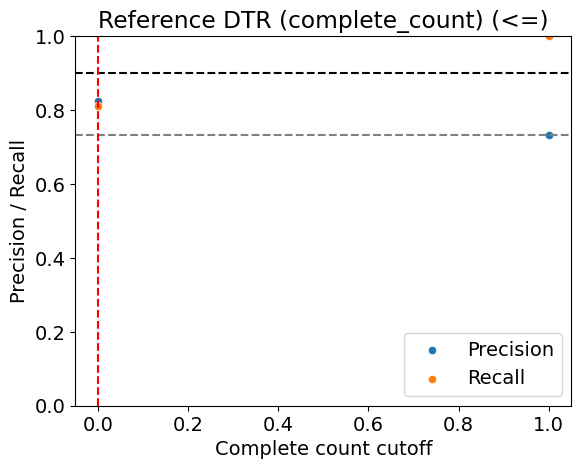

Reference DTR (complete_count) (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with complete_count > 0: 0.1891785150078989
Groups: 38 | n=3,460 | TP=2,532


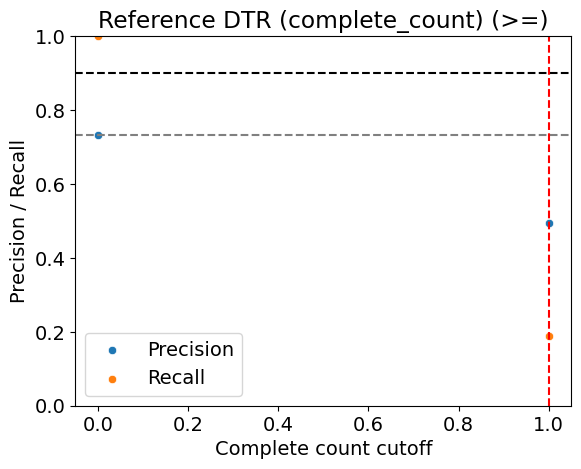

In [58]:
### Reference DTR (complete_count)
# complete_count is 0/1 here (species-rep CheckV Complete flag), not a genomovar sum.
plot_metric_pr(
    'complete_count', [0, 1], 'le',
    'Reference DTR (complete_count) (<=)',
    'Complete count cutoff',
    axvline=0,
)
plot_metric_pr(
    'complete_count', [0, 1], 'ge',
    'Reference DTR (complete_count) (>=)',
    'Complete count cutoff',
    axvline=1,
)


Integration gene proportion (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_prop_integration > 0: 0.9766982622432859
Groups: 38 | n=3,460 | TP=2,532


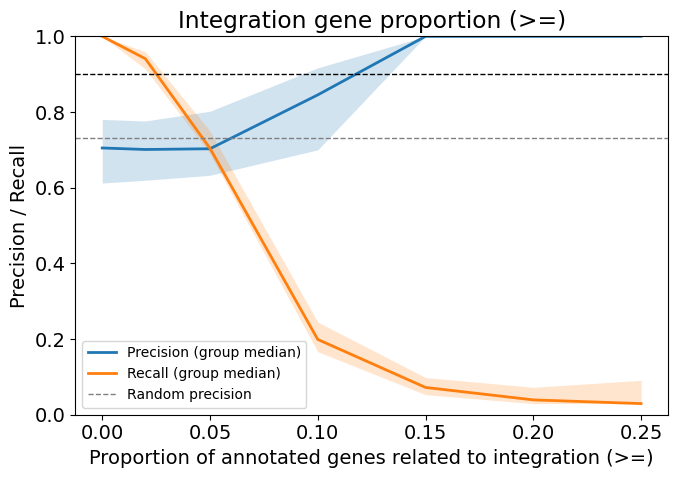

Integration gene proportion (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_prop_integration > 0: 0.9766982622432859
Groups: 38 | n=3,460 | TP=2,532


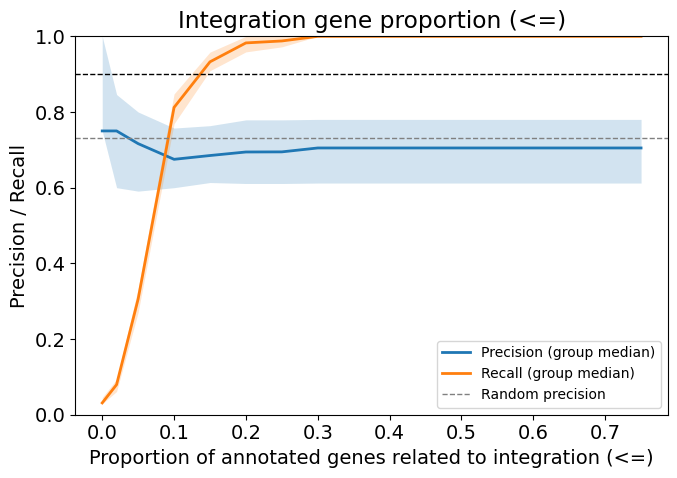

In [59]:
### Integration gene proportion (reference annotations)
# med_prop_integration = fraction of species-rep genes annotated as integration.
plot_metric_pr(
    'med_prop_integration', PROP_CUTOFFS, 'ge',
    'Integration gene proportion (>=)',
    'Proportion of annotated genes related to integration (>=)',
    grouped=True,
)
plot_metric_pr(
    'med_prop_integration', PROP_CUTOFFS, 'le',
    'Integration gene proportion (<=)',
    'Proportion of annotated genes related to integration (<=)',
    grouped=True,
)


Virulent score cutoff (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_virulent_score > 0: 0.7101105845181674
Groups: 38 | n=3,460 | TP=2,532


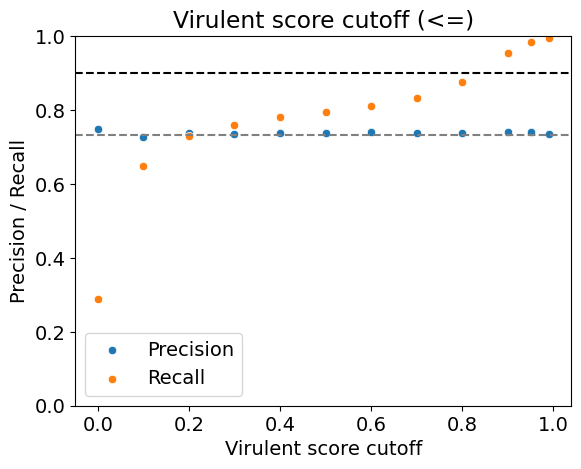

Virulent score cutoff (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_virulent_score > 0: 0.7101105845181674
Groups: 38 | n=3,460 | TP=2,532


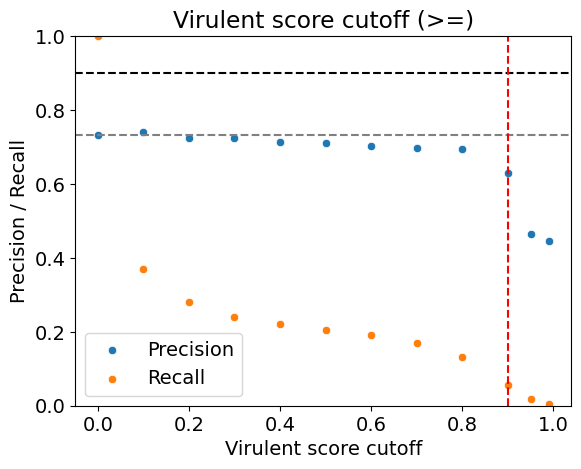

In [60]:
### Virulent score cutoff
plot_metric_pr(
    'med_virulent_score',
    [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    'le',
    'Virulent score cutoff (<=)',
    'Virulent score cutoff',
)
plot_metric_pr(
    'med_virulent_score',
    [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    'ge',
    'Virulent score cutoff (>=)',
    'Virulent score cutoff',
    axvline=0.9,
)


Reference hallmark genes (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_n_hallmarks > 0: 0.94826224328594
Groups: 38 | n=3,460 | TP=2,532


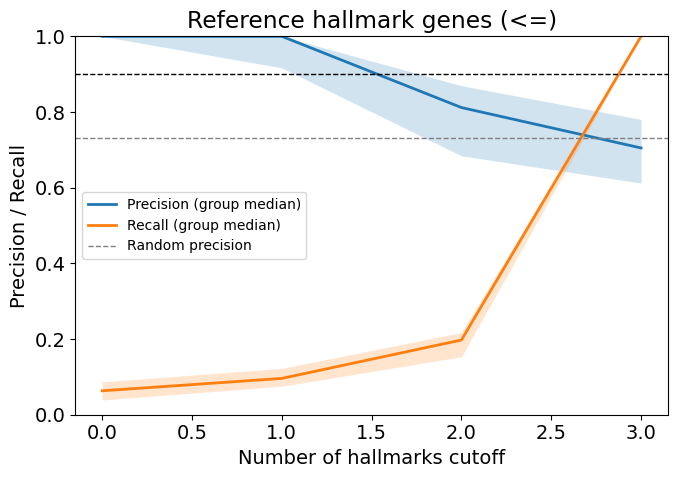

Reference hallmark genes (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_n_hallmarks > 0: 0.94826224328594
Groups: 38 | n=3,460 | TP=2,532


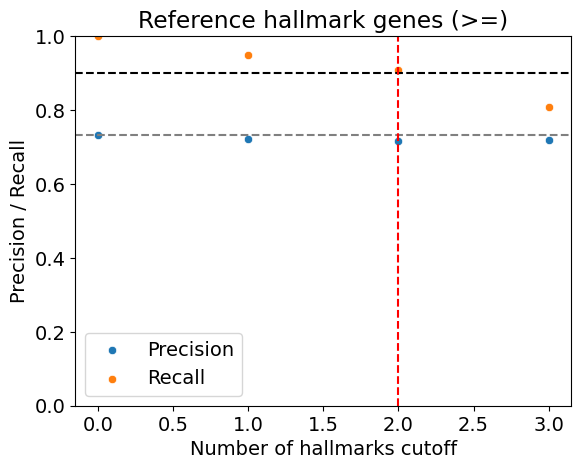

In [61]:
### Hallmark genes (reference MCP + terL + portal; range 0–3)
# Presence of each hallmark anywhere on the species-rep genome (not coverage-gated).
plot_metric_pr(
    'med_n_hallmarks', [0, 1, 2, 3], 'le',
    'Reference hallmark genes (<=)',
    'Number of hallmarks cutoff',
    grouped=True,
)
plot_metric_pr(
    'med_n_hallmarks', [0, 1, 2, 3], 'ge',
    'Reference hallmark genes (>=)',
    'Number of hallmarks cutoff',
    axvline=2,
)


Protein similarity to DTR (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_aai_id_af > 0: 1.0
Groups: 38 | n=3,460 | TP=2,532


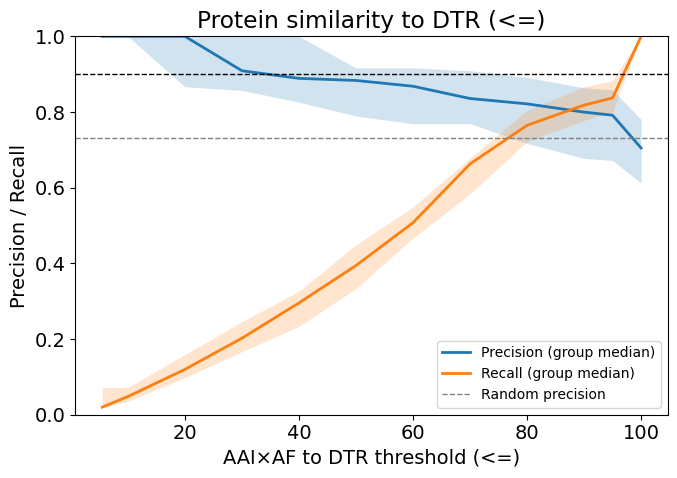

Protein similarity to DTR (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_aai_id_af > 0: 1.0
Groups: 38 | n=3,460 | TP=2,532


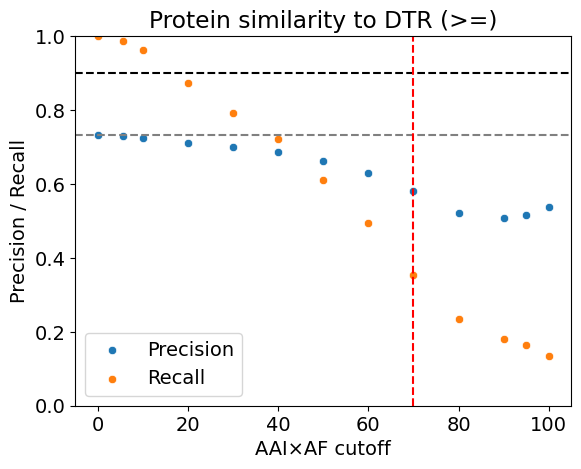

In [62]:
### Protein similarity to DTR
plot_metric_pr(
    'med_aai_id_af',
    [0, 5.5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100],
    'le',
    'Protein similarity to DTR (<=)',
    'AAI×AF to DTR threshold (<=)',
    grouped=True,
)
plot_metric_pr(
    'med_aai_id_af',
    [0, 5.5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100],
    'ge',
    'Protein similarity to DTR (>=)',
    'AAI×AF cutoff',
    # extra_filter=(pl.col('complete_count') == 0),
    axvline=70,
)


Lysis gene proportion (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_prop_lysis > 0: 0.8977093206951027
Groups: 38 | n=3,460 | TP=2,532


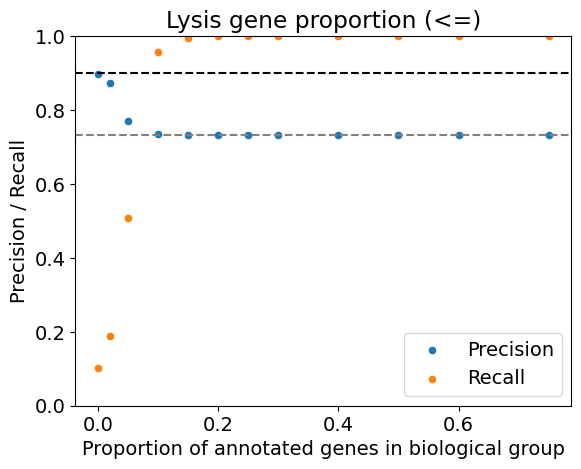

Lysis gene proportion (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_prop_lysis > 0: 0.8977093206951027
Groups: 38 | n=3,460 | TP=2,532


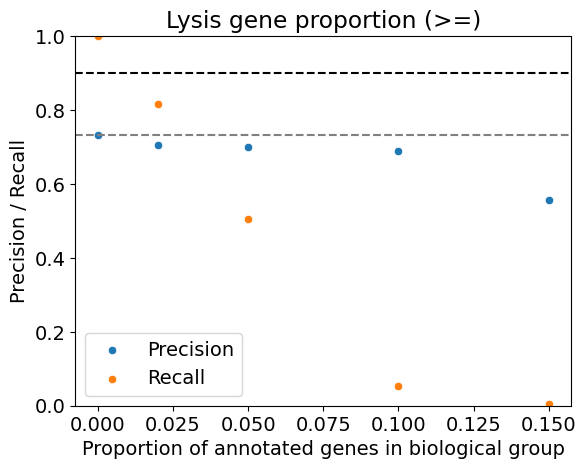

In [63]:
### Lysis gene proportion (reference annotations)
plot_metric_pr(
    'med_prop_lysis', PROP_CUTOFFS, 'le',
    'Lysis gene proportion (<=)',
    'Proportion of annotated genes in biological group',
)
plot_metric_pr(
    'med_prop_lysis', PROP_CUTOFFS, 'ge',
    'Lysis gene proportion (>=)',
    'Proportion of annotated genes in biological group',
)


Tail gene proportion (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_prop_tail > 0: 0.9553712480252765
Groups: 38 | n=3,460 | TP=2,532


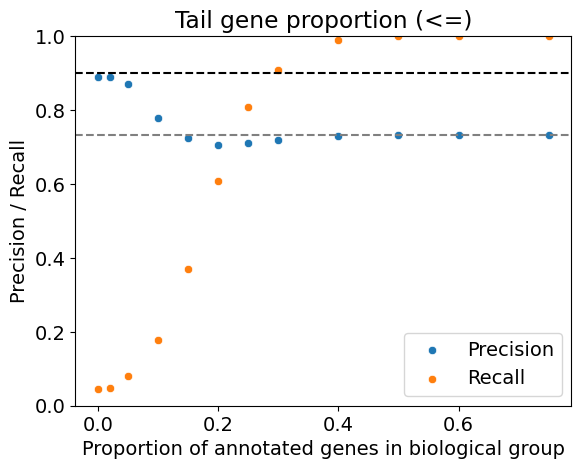

Tail gene proportion (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_prop_tail > 0: 0.9553712480252765
Groups: 38 | n=3,460 | TP=2,532


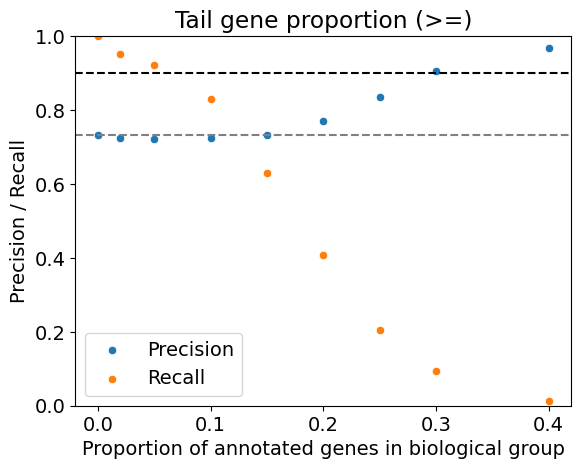

In [64]:
### Tail gene proportion (reference annotations)
plot_metric_pr(
    'med_prop_tail', PROP_CUTOFFS, 'le',
    'Tail gene proportion (<=)',
    'Proportion of annotated genes in biological group',
)
plot_metric_pr(
    'med_prop_tail', PROP_CUTOFFS, 'ge',
    'Tail gene proportion (>=)',
    'Proportion of annotated genes in biological group',
)


Capsid/packaging gene proportion (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_prop_capsid_packaging > 0: 0.9743285939968405
Groups: 38 | n=3,460 | TP=2,532


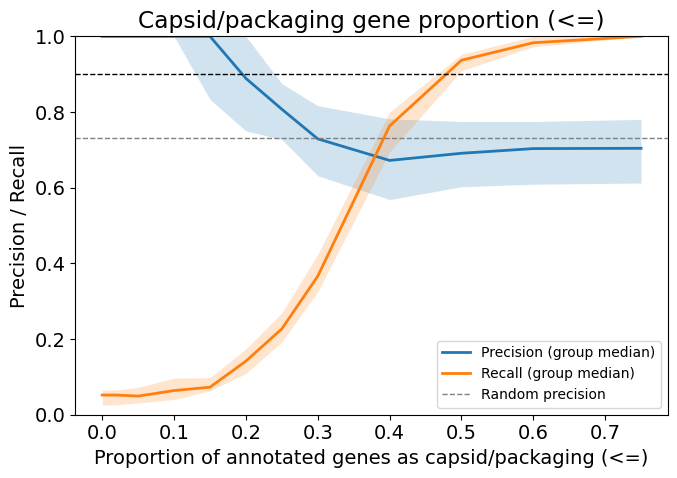

Capsid/packaging gene proportion (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_prop_capsid_packaging > 0: 0.9743285939968405
Groups: 38 | n=3,460 | TP=2,532


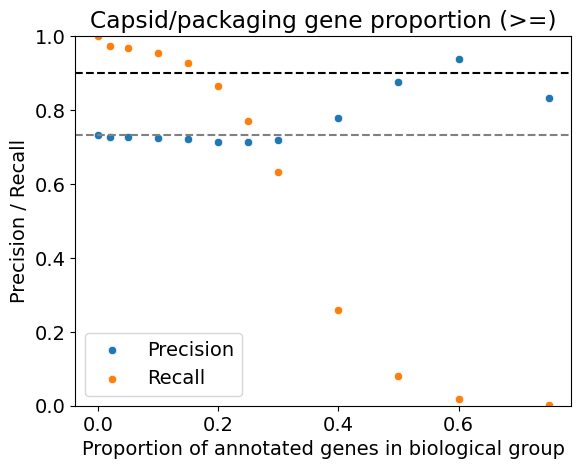

In [65]:
### Capsid/packaging gene proportion (reference annotations)
plot_metric_pr(
    'med_prop_capsid_packaging', PROP_CUTOFFS, 'le',
    'Capsid/packaging gene proportion (<=)',
    'Proportion of annotated genes as capsid/packaging (<=)',
    grouped=True,
)
plot_metric_pr(
    'med_prop_capsid_packaging', PROP_CUTOFFS, 'ge',
    'Capsid/packaging gene proportion (>=)',
    'Proportion of annotated genes in biological group',
)


DNA metabolism gene proportion (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_prop_dna_metabolism > 0: 1.0
Groups: 38 | n=3,460 | TP=2,532


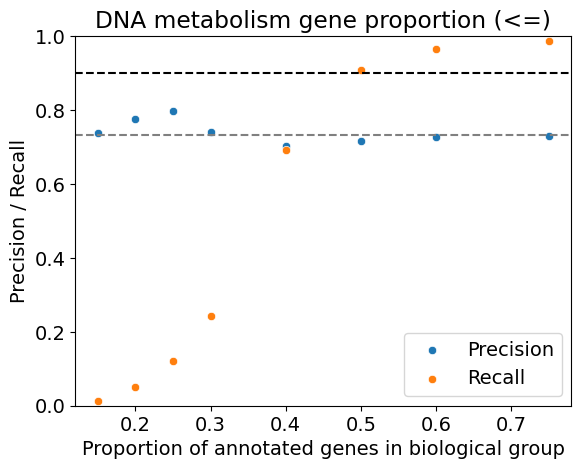

DNA metabolism gene proportion (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_prop_dna_metabolism > 0: 1.0
Groups: 38 | n=3,460 | TP=2,532


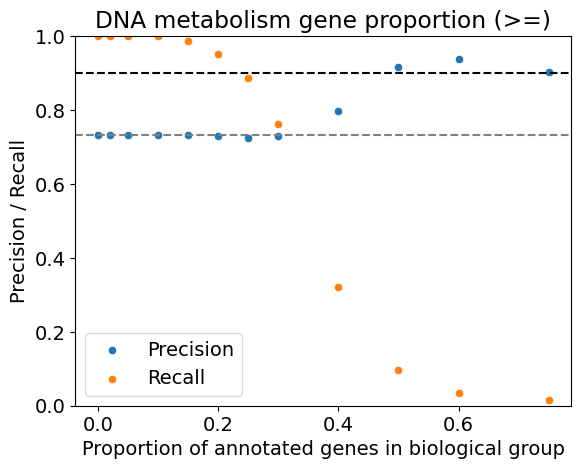

In [66]:
### DNA metabolism gene proportion (reference annotations)
plot_metric_pr(
    'med_prop_dna_metabolism', PROP_CUTOFFS, 'le',
    'DNA metabolism gene proportion (<=)',
    'Proportion of annotated genes in biological group',
)
plot_metric_pr(
    'med_prop_dna_metabolism', PROP_CUTOFFS, 'ge',
    'DNA metabolism gene proportion (>=)',
    'Proportion of annotated genes in biological group',
)


AMG / host takeover gene proportion (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_prop_amg_host_takeover > 0: 0.6796998420221169
Groups: 38 | n=3,460 | TP=2,532


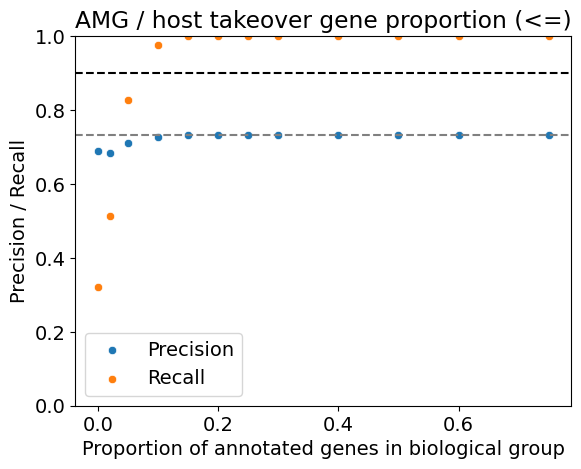

AMG / host takeover gene proportion (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_prop_amg_host_takeover > 0: 0.6796998420221169
Groups: 38 | n=3,460 | TP=2,532


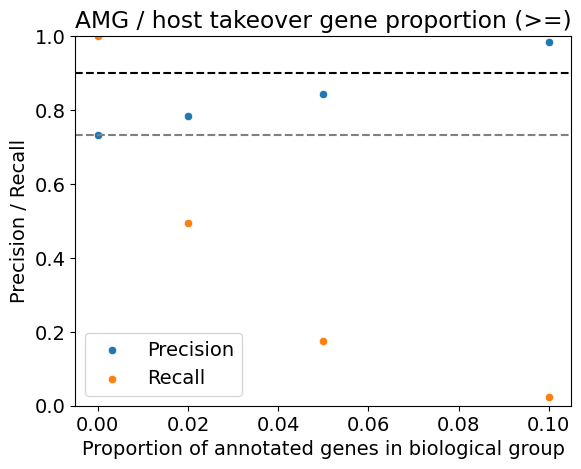

In [67]:
### AMG / host takeover gene proportion (reference annotations)
plot_metric_pr(
    'med_prop_amg_host_takeover', PROP_CUTOFFS, 'le',
    'AMG / host takeover gene proportion (<=)',
    'Proportion of annotated genes in biological group',
)
plot_metric_pr(
    'med_prop_amg_host_takeover', PROP_CUTOFFS, 'ge',
    'AMG / host takeover gene proportion (>=)',
    'Proportion of annotated genes in biological group',
)


CheckV host genes (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with host_genes > 0: 0.7030015797788309
Groups: 38 | n=3,460 | TP=2,532


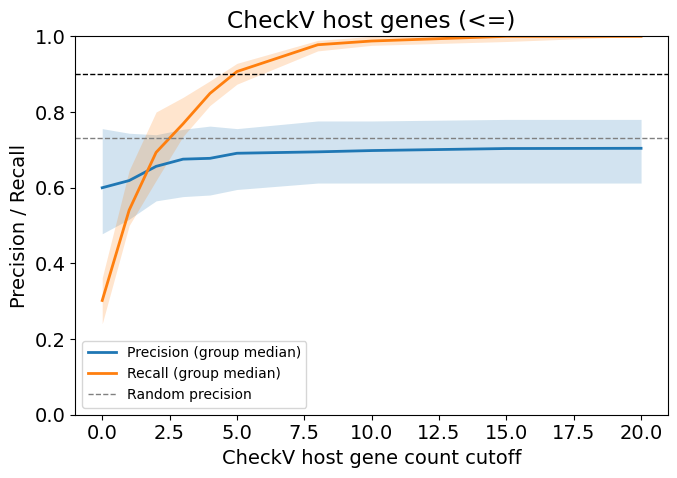

CheckV host genes (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with host_genes > 0: 0.7030015797788309
Groups: 38 | n=3,460 | TP=2,532


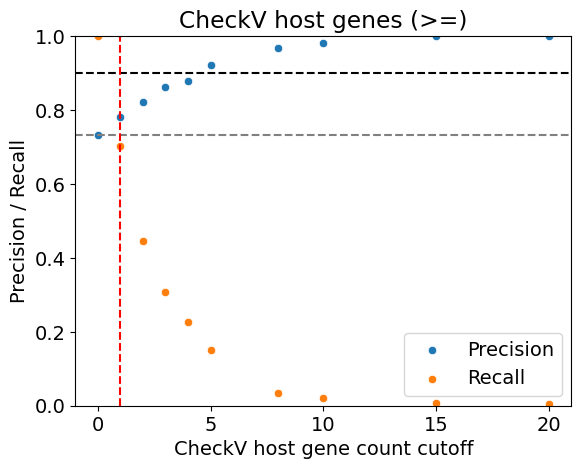

In [68]:
### CheckV host genes
# host_genes is the CheckV host-gene count on the species-rep genome.
plot_metric_pr(
    'host_genes', [0, 1, 2, 3, 4, 5, 8, 10, 15, 20], 'le',
    'CheckV host genes (<=)',
    'CheckV host gene count cutoff',
    grouped=True,
)
plot_metric_pr(
    'host_genes', [0, 1, 2, 3, 4, 5, 8, 10, 15, 20], 'ge',
    'CheckV host genes (>=)',
    'CheckV host gene count cutoff',
    axvline=1,
)


geNomad virus score (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with virus_score > 0: 1.0
Groups: 38 | n=3,460 | TP=2,532


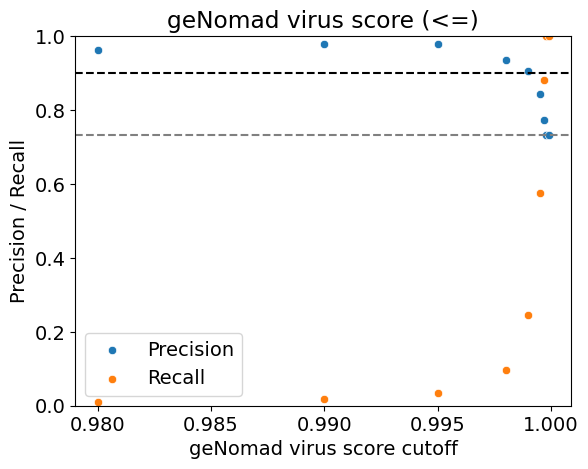

geNomad virus score (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with virus_score > 0: 1.0
Groups: 38 | n=3,460 | TP=2,532


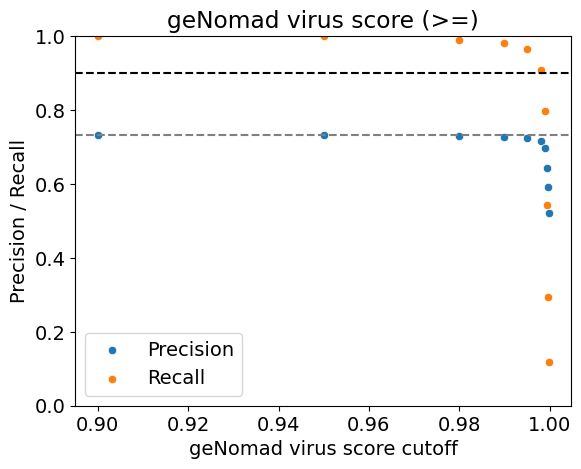

In [69]:
### geNomad virus score
# virus_score in UHVDB metadata is the geNomad virus score stored by CheckV (typically ~0.99–1.0).
plot_metric_pr(
    'virus_score',
    [0.9, 0.95, 0.98, 0.99, 0.995, 0.998, 0.999, 0.9995, 0.9997, 0.9998, 0.9999],
    'le',
    'geNomad virus score (<=)',
    'geNomad virus score cutoff',
)
plot_metric_pr(
    'virus_score',
    [0.9, 0.95, 0.98, 0.99, 0.995, 0.998, 0.999, 0.9995, 0.9997, 0.9998, 0.9999],
    'ge',
    'geNomad virus score (>=)',
    'geNomad virus score cutoff',
)


Mean capsid/packaging gene length (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with mean_len_aa_capsid_packaging > 0: 0.9743285939968405
Groups: 38 | n=3,460 | TP=2,532


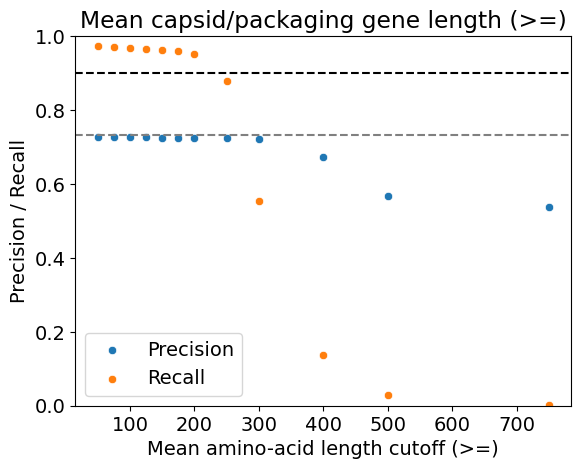

Mean capsid/packaging gene length (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with mean_len_aa_capsid_packaging > 0: 0.9743285939968405
Groups: 38 | n=3,460 | TP=2,532


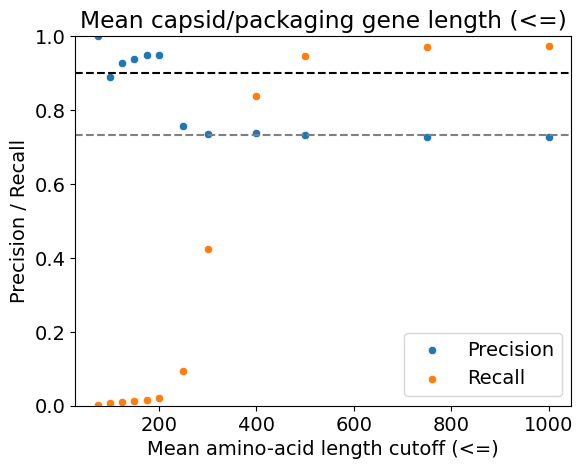

Mean dna/metabolism gene length (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with mean_len_aa_dna_metabolism > 0: 1.0
Groups: 38 | n=3,460 | TP=2,532


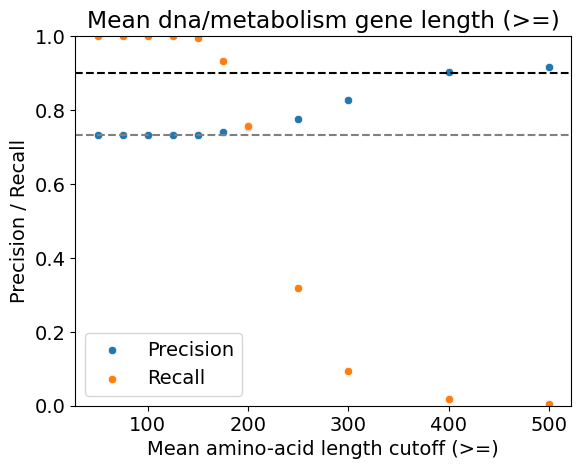

Mean dna/metabolism gene length (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with mean_len_aa_dna_metabolism > 0: 1.0
Groups: 38 | n=3,460 | TP=2,532


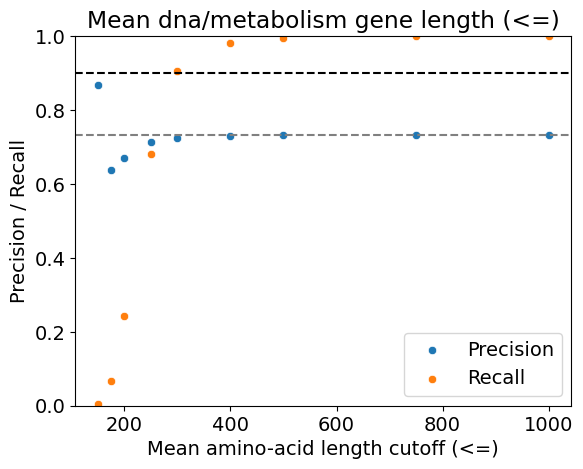

Mean tail gene length (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with mean_len_aa_tail > 0: 0.9553712480252765
Groups: 38 | n=3,460 | TP=2,532


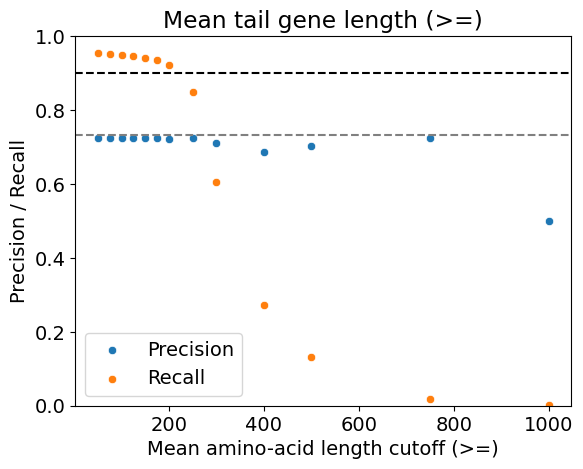

Mean tail gene length (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with mean_len_aa_tail > 0: 0.9553712480252765
Groups: 38 | n=3,460 | TP=2,532


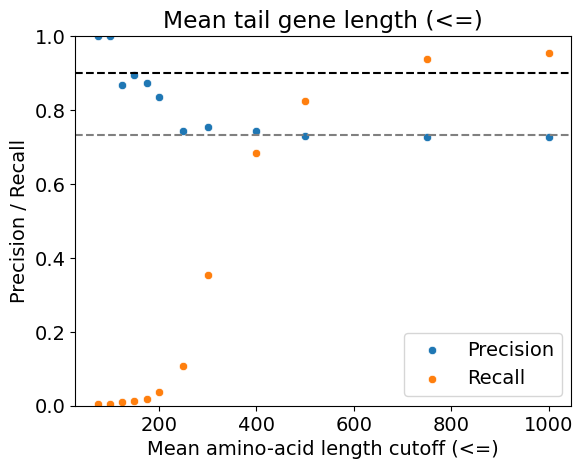

Mean lysis gene length (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with mean_len_aa_lysis > 0: 0.8977093206951027
Groups: 38 | n=3,460 | TP=2,532


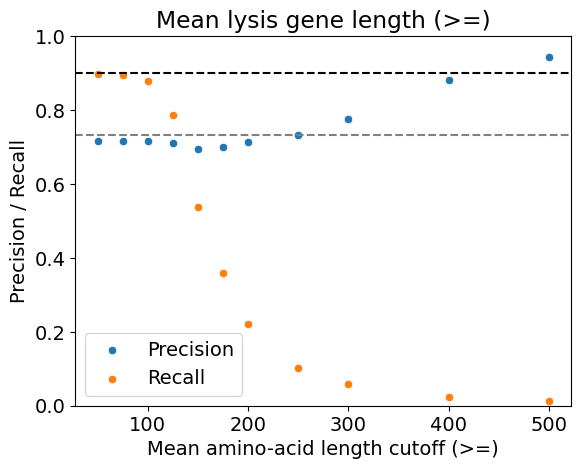

Mean lysis gene length (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with mean_len_aa_lysis > 0: 0.8977093206951027
Groups: 38 | n=3,460 | TP=2,532


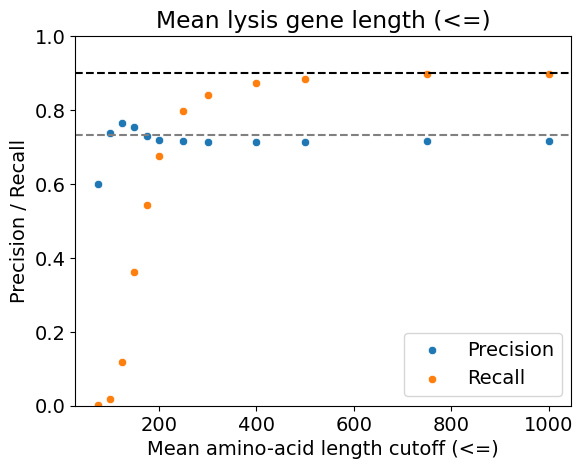

Mean connector gene length (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with mean_len_aa_connector > 0: 0.8195102685624013
Groups: 38 | n=3,460 | TP=2,532


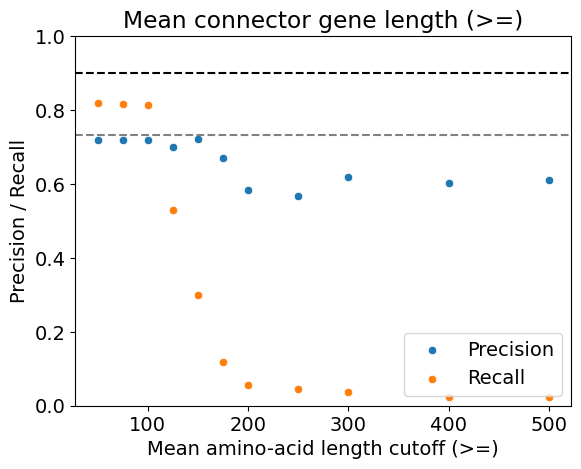

Mean connector gene length (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with mean_len_aa_connector > 0: 0.8195102685624013
Groups: 38 | n=3,460 | TP=2,532


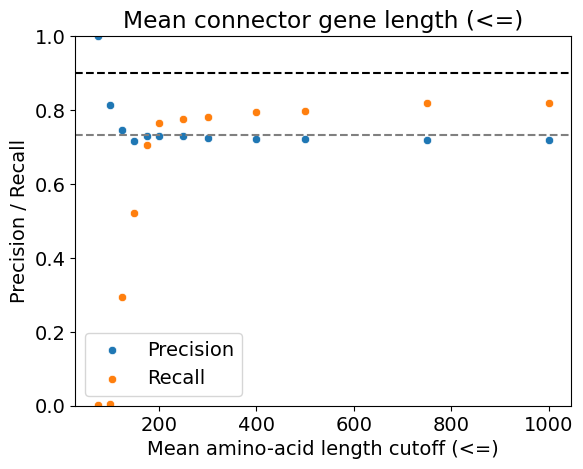

Mean transcription gene length (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with mean_len_aa_transcription > 0: 0.9798578199052133
Groups: 38 | n=3,460 | TP=2,532


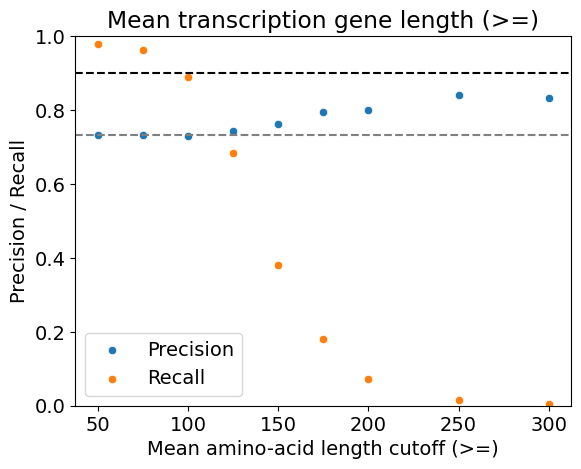

Mean transcription gene length (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with mean_len_aa_transcription > 0: 0.9798578199052133
Groups: 38 | n=3,460 | TP=2,532


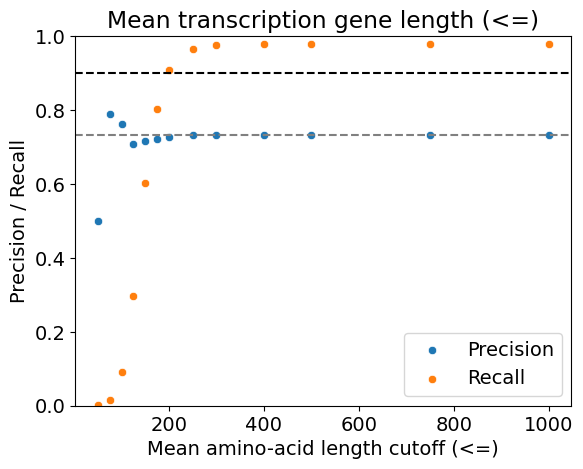

Mean integration gene length (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with mean_len_aa_integration > 0: 0.9766982622432859
Groups: 38 | n=3,460 | TP=2,532


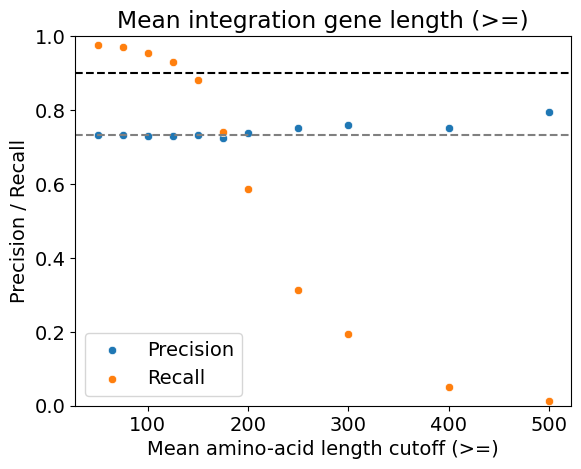

Mean integration gene length (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with mean_len_aa_integration > 0: 0.9766982622432859
Groups: 38 | n=3,460 | TP=2,532


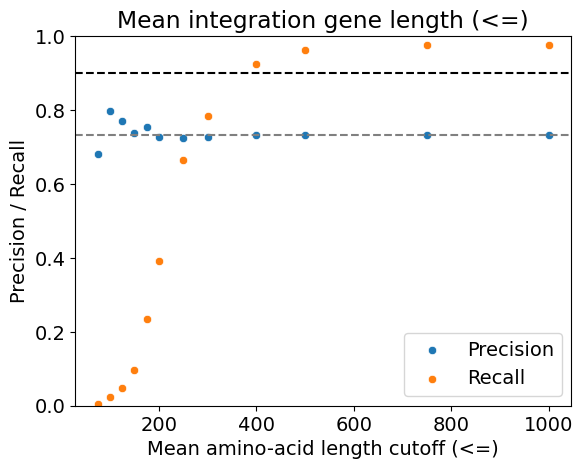

Mean amg/host/takeover gene length (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with mean_len_aa_amg_host_takeover > 0: 0.6796998420221169
Groups: 38 | n=3,460 | TP=2,532


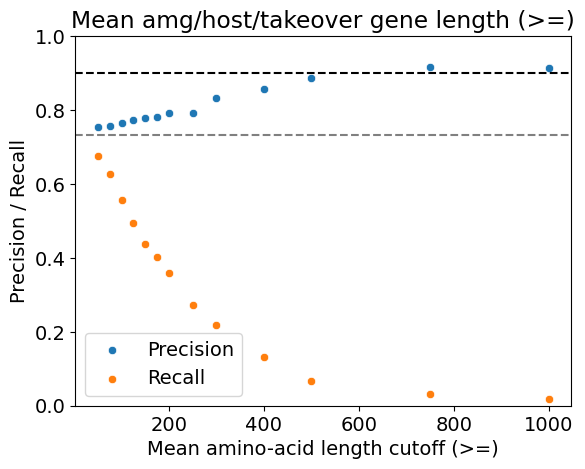

Mean amg/host/takeover gene length (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with mean_len_aa_amg_host_takeover > 0: 0.6796998420221169
Groups: 38 | n=3,460 | TP=2,532


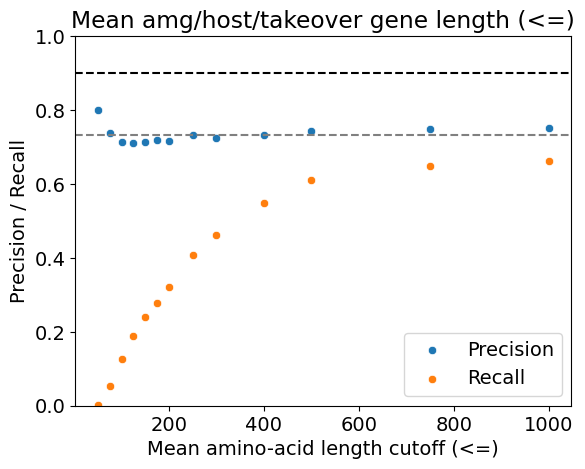

Mean all genes gene length (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with mean_len_aa_all > 0: 1.0
Groups: 38 | n=3,460 | TP=2,532


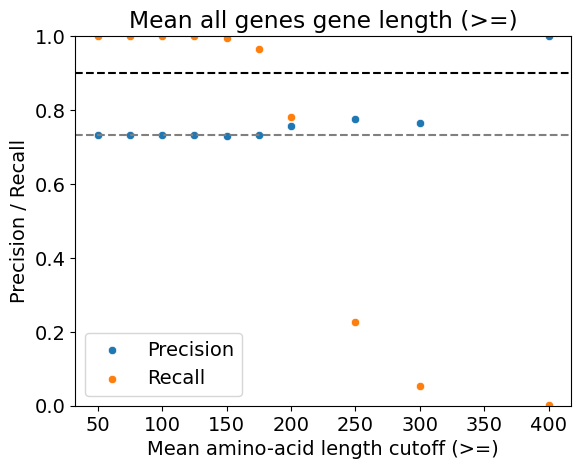

Mean all genes gene length (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with mean_len_aa_all > 0: 1.0
Groups: 38 | n=3,460 | TP=2,532


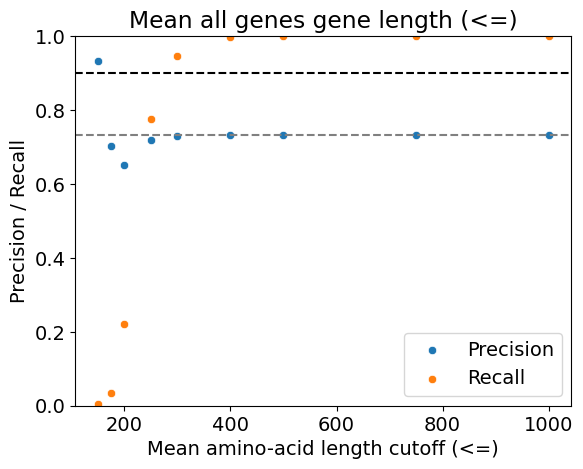

In [70]:
### Mean amino-acid gene length by biological group
# Length = (end - start + 1) / 3 on the species-rep genome. Null if the genome
# has no genes in that group (not filled as 0).
LEN_PLOT_GROUPS = LENGTH_GROUPS + ['all']
for g in LEN_PLOT_GROUPS:
    pretty = 'all genes' if g == 'all' else g.replace('_', '/')
    col = f'mean_len_aa_{g}'
    plot_metric_pr(
        col, LEN_CUTOFFS, 'ge',
        f'Mean {pretty} gene length (>=)',
        'Mean amino-acid length cutoff (>=)',
    )
    plot_metric_pr(
        col, LEN_CUTOFFS, 'le',
        f'Mean {pretty} gene length (<=)',
        'Mean amino-acid length cutoff (<=)',
    )


Median capsid/packaging gene length (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_len_aa_capsid_packaging > 0: 0.9743285939968405
Groups: 38 | n=3,460 | TP=2,532


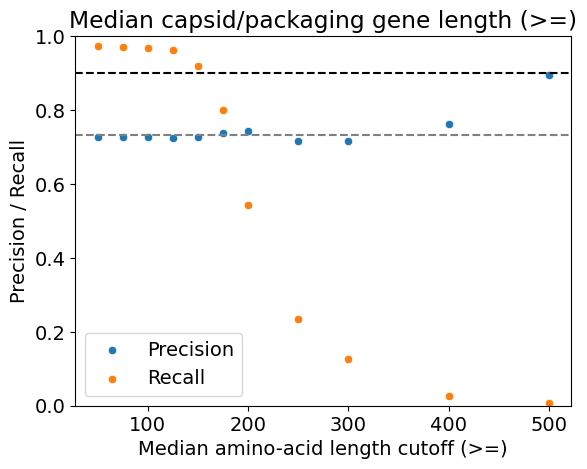

Median capsid/packaging gene length (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_len_aa_capsid_packaging > 0: 0.9743285939968405
Groups: 38 | n=3,460 | TP=2,532


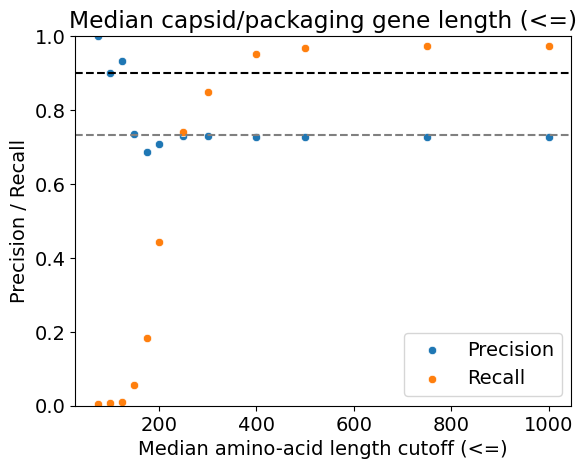

Median dna/metabolism gene length (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_len_aa_dna_metabolism > 0: 1.0
Groups: 38 | n=3,460 | TP=2,532


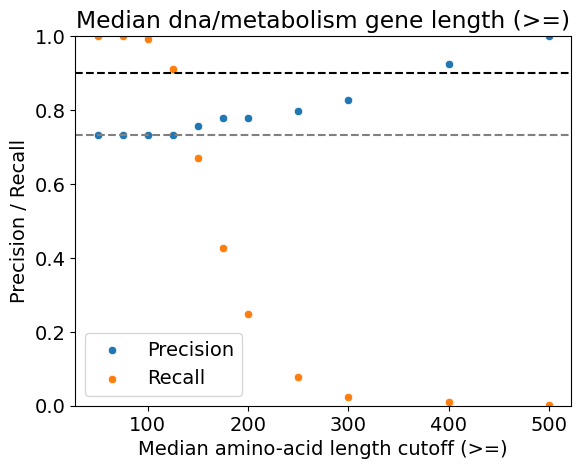

Median dna/metabolism gene length (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_len_aa_dna_metabolism > 0: 1.0
Groups: 38 | n=3,460 | TP=2,532


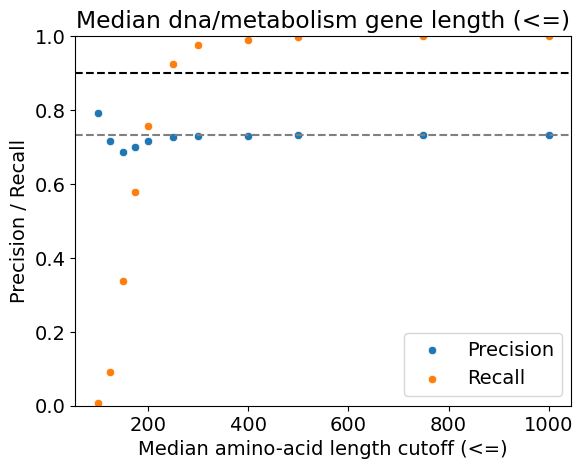

Median tail gene length (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_len_aa_tail > 0: 0.9553712480252765
Groups: 38 | n=3,460 | TP=2,532


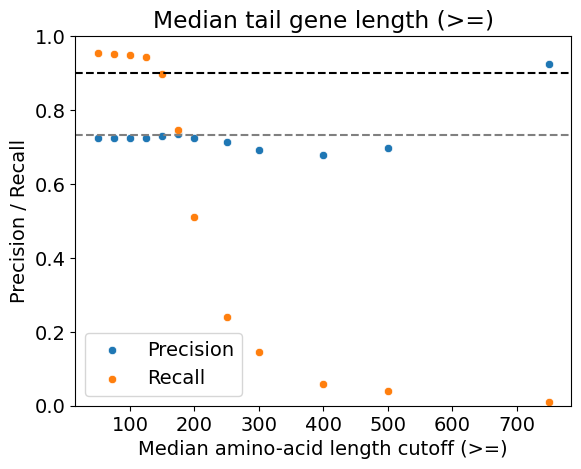

Median tail gene length (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_len_aa_tail > 0: 0.9553712480252765
Groups: 38 | n=3,460 | TP=2,532


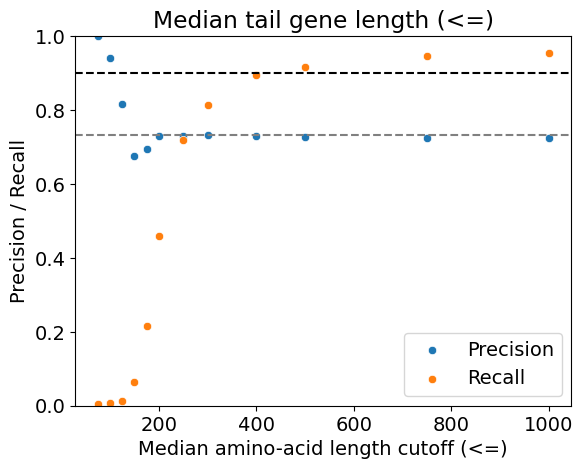

Median lysis gene length (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_len_aa_lysis > 0: 0.8977093206951027
Groups: 38 | n=3,460 | TP=2,532


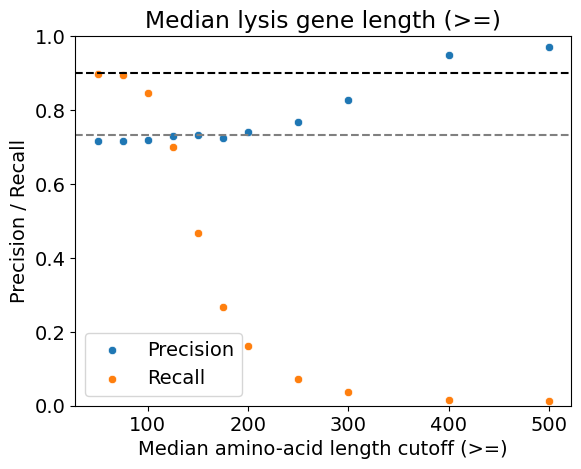

Median lysis gene length (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_len_aa_lysis > 0: 0.8977093206951027
Groups: 38 | n=3,460 | TP=2,532


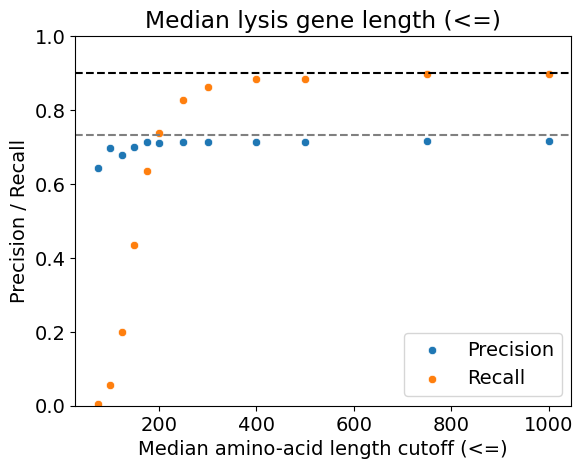

Median connector gene length (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_len_aa_connector > 0: 0.8195102685624013
Groups: 38 | n=3,460 | TP=2,532


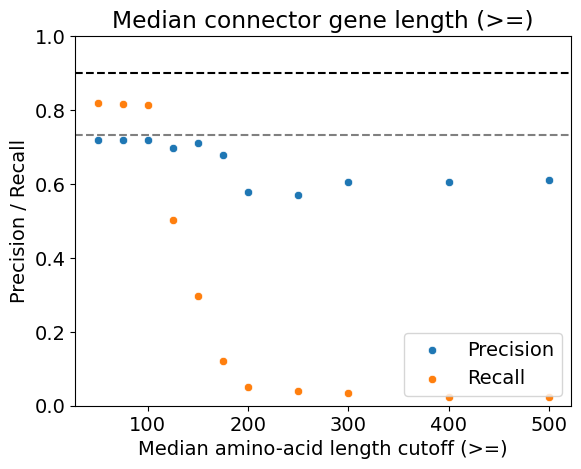

Median connector gene length (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_len_aa_connector > 0: 0.8195102685624013
Groups: 38 | n=3,460 | TP=2,532


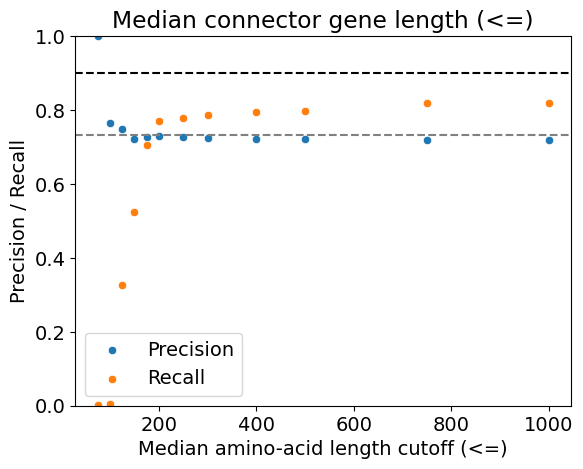

Median transcription gene length (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_len_aa_transcription > 0: 0.9798578199052133
Groups: 38 | n=3,460 | TP=2,532


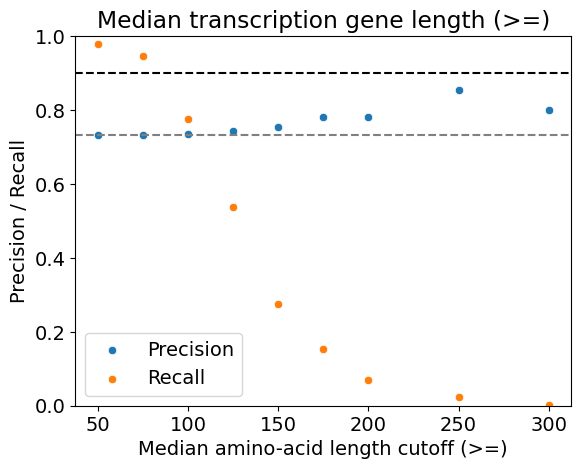

Median transcription gene length (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_len_aa_transcription > 0: 0.9798578199052133
Groups: 38 | n=3,460 | TP=2,532


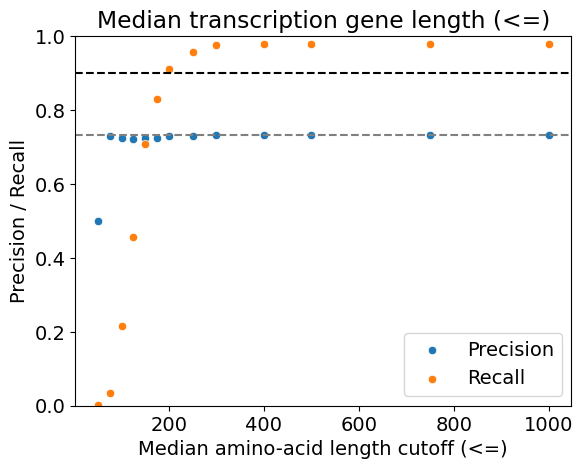

Median integration gene length (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_len_aa_integration > 0: 0.9766982622432859
Groups: 38 | n=3,460 | TP=2,532


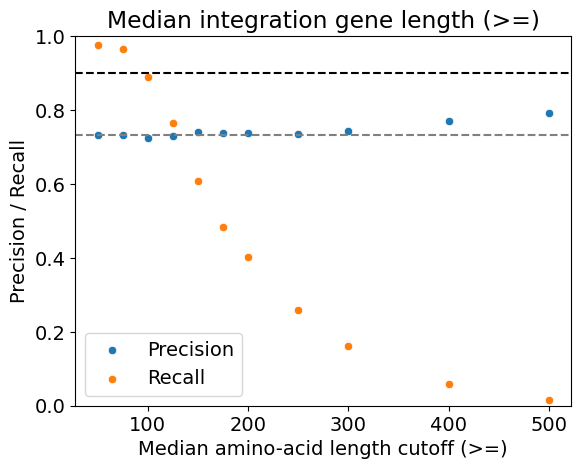

Median integration gene length (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_len_aa_integration > 0: 0.9766982622432859
Groups: 38 | n=3,460 | TP=2,532


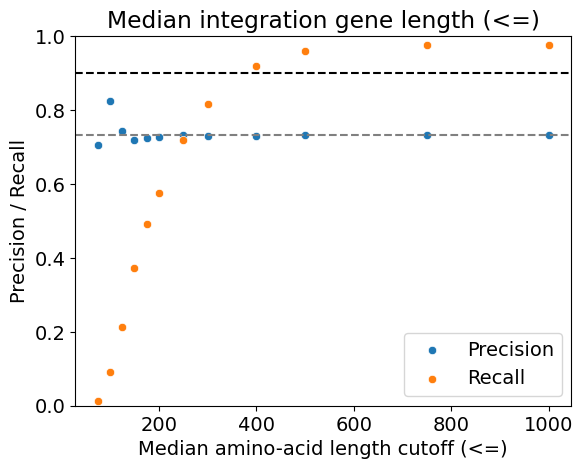

Median amg/host/takeover gene length (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_len_aa_amg_host_takeover > 0: 0.6796998420221169
Groups: 38 | n=3,460 | TP=2,532


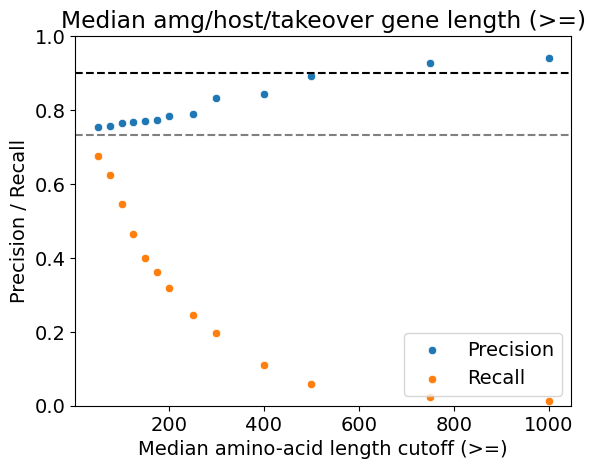

Median amg/host/takeover gene length (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_len_aa_amg_host_takeover > 0: 0.6796998420221169
Groups: 38 | n=3,460 | TP=2,532


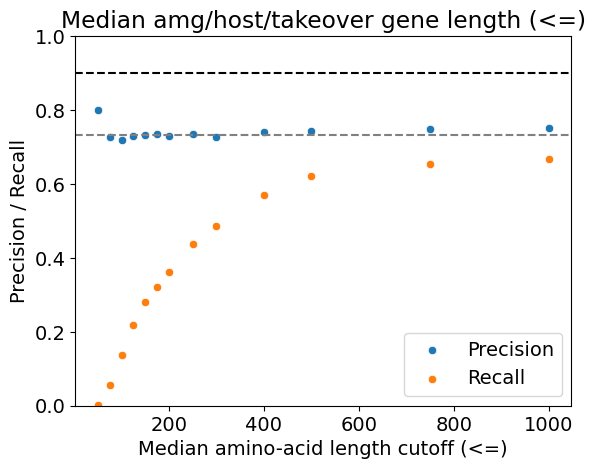

Median all genes gene length (>=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_len_aa_all > 0: 1.0
Groups: 38 | n=3,460 | TP=2,532


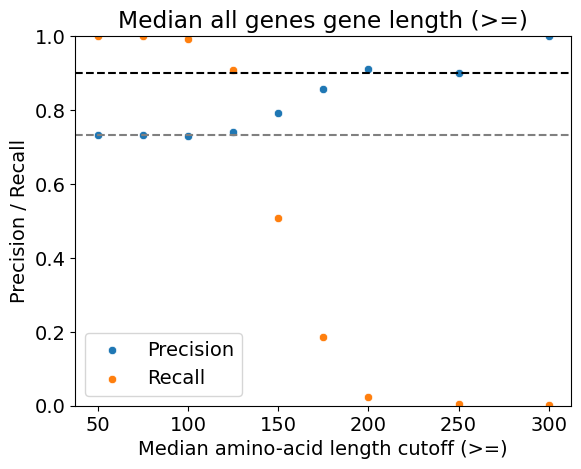

Median all genes gene length (<=)
Baseline check: 0.7317919075144509
Fraction of TPs with med_len_aa_all > 0: 1.0
Groups: 38 | n=3,460 | TP=2,532


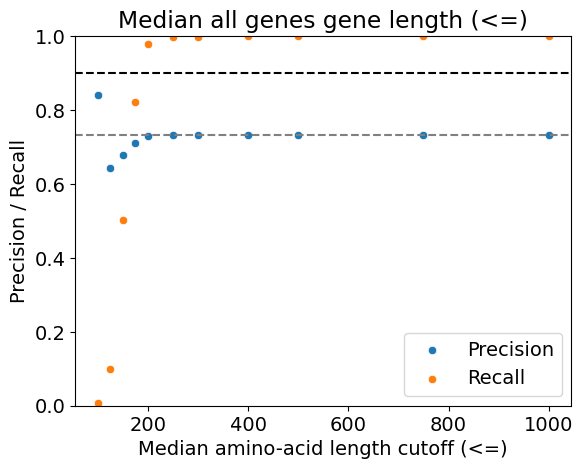

In [71]:
### Median amino-acid gene length by biological group
# Length = (end - start + 1) / 3 on the species-rep genome. Null if the genome
# has no genes in that group (not filled as 0).
LEN_PLOT_GROUPS = LENGTH_GROUPS + ['all']
for g in LEN_PLOT_GROUPS:
    pretty = 'all genes' if g == 'all' else g.replace('_', '/')
    col = f'med_len_aa_{g}'
    plot_metric_pr(
        col, LEN_CUTOFFS, 'ge',
        f'Median {pretty} gene length (>=)',
        'Median amino-acid length cutoff (>=)',
    )
    plot_metric_pr(
        col, LEN_CUTOFFS, 'le',
        f'Median {pretty} gene length (<=)',
        'Median amino-acid length cutoff (<=)',
    )


### Classifier: inactive vs active from reference annotations only

Retrain the figure_s15 inactive-virus RandomForest on **genome-static** features:
species-rep metadata plus the annotation-derived gene proportions / hallmarks /
mean and median amino-acid gene lengths above.
CoverM breadth, gene-breadth occupancy, and Sylph coverage/ANI features are excluded.

Saved as `phage_activity_model_ref_only.joblib` and
`phage_model_metadata_ref_only.joblib` (does not overwrite the coverage-based model).


In [72]:
# Feature table for classifier — reference annotations only (Caudoviricetes)
REF_ONLY_FEATURES = [
    'complete_count',
    'high_quality_count',
    'med_virulent_score',
    'med_n_hallmarks',
    'med_aai_id_af',
    'med_prop_capsid_packaging',
    'med_prop_dna_metabolism',
    'med_prop_tail',
    'med_prop_lysis',
    'med_prop_connector',
    'med_prop_transcription',
    'med_prop_integration',
    'med_prop_amg_host_takeover',
    'med_mcp_hallmark',
    'med_portal_hallmark',
    'med_terL_hallmark',
    'log_contig_length',
    'log_n_genes',
    'completeness',
    'virus_score',
    'is_provirus',
    'host_genes',
    'viral_genes',
    'temperate',
    'annot_virulent',
    'phrog_integrases',
    'phrog_integration_excision',
    'empathi_integration',
    'is_integrated',
    'phrog_integrases_per_kb',
    'phrog_integration_excision_per_kb',
    'empathi_integration_per_kb',
    'num_lysis',
    'num_tail',
    'num_capsid',
    'num_proteins',
    'num_lysis_per_kb',
    'num_tail_per_kb',
    'num_capsid_per_kb',
    'num_proteins_per_kb',
    'annot_mcp_hallmark',
    'annot_terl_hallmark',
    'annot_portal_hallmark',
    'annot_n_hallmarks',
    'virus_hallmarks',
    'annot_n_hallmarks_per_kb',
    'virus_hallmarks_per_kb',
    'annot_aai_id',
    'annot_aai_af',
    'aai_completeness',
    'aai_confidence_ord',
    'Score',
    'kmer_freq',
    'has_terminal_repeats',
    'is_DTR',
    'is_ITR',
    'is_topology_provirus',
    'proviral_frac',
    'cm_dtr',
    'n_struct_genes',
    'mean_len_aa_all',
    'med_len_aa_all',
    *[c for g in LENGTH_GROUPS for c in (f'mean_len_aa_{g}', f'med_len_aa_{g}')],
]

_meta_sp = (
    uhvdb_final_metadata
    .filter(pl.col('uhvdb_id') == pl.col('species_rep'))
    .unique('species_cluster_id', keep='first')
    .with_columns(pl.col('species_cluster_id').cast(pl.Int64))
    .with_columns([
        pl.col('virulent').alias('annot_virulent'),
        pl.col('temperate'),
        pl.col('phrog_integrases').cast(pl.Float64),
        pl.col('phrog_integration_excision').cast(pl.Float64),
        pl.col('empathi_integration').cast(pl.Float64),
        (pl.col('integration_status') == 'integrated').cast(pl.Float64).alias('is_integrated'),
        (pl.col('provirus').cast(pl.Utf8).str.to_lowercase().is_in(['yes', 'true', '1'])).cast(pl.Float64).alias('is_provirus'),
        pl.col('num_lysis').cast(pl.Float64),
        pl.col('num_tail').cast(pl.Float64),
        pl.col('num_capsid').cast(pl.Float64),
        pl.col('num_proteins').cast(pl.Float64),
        pl.col('mcp_hallmark').cast(pl.Float64).alias('annot_mcp_hallmark'),
        pl.col('terl_hallmark').cast(pl.Float64).alias('annot_terl_hallmark'),
        pl.col('portal_hallmark').cast(pl.Float64).alias('annot_portal_hallmark'),
        pl.col('n_hallmarks').cast(pl.Float64).alias('annot_n_hallmarks'),
        pl.col('virus_hallmarks').cast(pl.Float64),
        pl.col('aai_id').alias('annot_aai_id'),
        pl.col('aai_af').alias('annot_aai_af'),
        pl.col('aai_completeness'),
        pl.when(pl.col('aai_confidence') == 'low').then(0.0)
          .when(pl.col('aai_confidence') == 'medium').then(1.0)
          .when(pl.col('aai_confidence') == 'high').then(2.0)
          .otherwise(1.0)
          .alias('aai_confidence_ord'),
        pl.col('Score'),
        pl.col('kmer_freq'),
        pl.col('completeness'),
        pl.col('virus_score'),
        pl.col('host_genes'),
        pl.col('viral_genes'),
        pl.col('contig_length'),
        pl.col('n_genes'),
        pl.col('topology').is_in(['DTR', 'ITR']).cast(pl.Float64).alias('has_terminal_repeats'),
        (pl.col('topology') == 'DTR').cast(pl.Float64).alias('is_DTR'),
        (pl.col('topology') == 'ITR').cast(pl.Float64).alias('is_ITR'),
        (pl.col('topology') == 'Provirus').cast(pl.Float64).alias('is_topology_provirus'),
        (
            pl.col('proviral_length').cast(pl.Utf8).replace('NA', None).cast(pl.Float64, strict=False)
            / pl.col('contig_length')
        ).alias('proviral_frac'),
        pl.col('completeness_method').cast(pl.Utf8).str.contains('DTR').cast(pl.Float64).alias('cm_dtr'),
    ])
    .with_columns([
        (pl.col('num_lysis') / (pl.col('contig_length') / 1000)).alias('num_lysis_per_kb'),
        (pl.col('num_tail') / (pl.col('contig_length') / 1000)).alias('num_tail_per_kb'),
        (pl.col('num_capsid') / (pl.col('contig_length') / 1000)).alias('num_capsid_per_kb'),
        (pl.col('num_proteins') / (pl.col('contig_length') / 1000)).alias('num_proteins_per_kb'),
        (pl.col('phrog_integrases') / (pl.col('contig_length') / 1000)).alias('phrog_integrases_per_kb'),
        (pl.col('phrog_integration_excision') / (pl.col('contig_length') / 1000)).alias('phrog_integration_excision_per_kb'),
        (pl.col('empathi_integration') / (pl.col('contig_length') / 1000)).alias('empathi_integration_per_kb'),
        (pl.col('annot_n_hallmarks') / (pl.col('contig_length') / 1000)).alias('annot_n_hallmarks_per_kb'),
        (pl.col('virus_hallmarks') / (pl.col('contig_length') / 1000)).alias('virus_hallmarks_per_kb'),
        pl.col('contig_length').log1p().alias('log_contig_length'),
        pl.col('n_genes').log1p().alias('log_n_genes'),
    ])
    .select([
        'species_cluster_id',
        'annot_virulent', 'temperate', 'phrog_integrases', 'phrog_integration_excision', 'empathi_integration',
        'is_integrated', 'is_provirus',
        'num_lysis', 'num_tail', 'num_capsid', 'num_proteins',
        'num_lysis_per_kb', 'num_tail_per_kb', 'num_capsid_per_kb', 'num_proteins_per_kb',
        'phrog_integrases_per_kb', 'phrog_integration_excision_per_kb', 'empathi_integration_per_kb',
        'annot_mcp_hallmark', 'annot_terl_hallmark', 'annot_portal_hallmark', 'annot_n_hallmarks', 'virus_hallmarks',
        'annot_n_hallmarks_per_kb', 'virus_hallmarks_per_kb',
        'annot_aai_id', 'annot_aai_af', 'aai_completeness', 'aai_confidence_ord', 'Score', 'kmer_freq',
        'completeness', 'virus_score', 'host_genes', 'viral_genes',
        'log_contig_length', 'log_n_genes', 'n_genes',
        'has_terminal_repeats', 'is_DTR', 'is_ITR', 'is_topology_provirus', 'proviral_frac', 'cm_dtr',
    ])
)

enrich_v_unenrich_final = (
    enrich_v_unenrich
    .with_columns(pl.col('species_cluster_id').cast(pl.Int64))
    .join(_meta_sp, on='species_cluster_id', how='left')
)

_missing = [c for c in REF_ONLY_FEATURES if c not in enrich_v_unenrich_final.columns]
if _missing:
    raise KeyError(f'Reference-only features missing from feature table: {_missing}')

enrich_v_unenrich_final = (
    enrich_v_unenrich_final
    .select(['group', 'species_cluster_id', 'pr_cat'] + REF_ONLY_FEATURES)
    .sort(['group', 'species_cluster_id'])
)

ANN_FEATURE_PREFIXES = (
    'med_prop_', 'med_mcp_', 'med_portal_', 'med_terL_', 'med_n_hallmarks',
    'n_struct_genes', 'mean_len_aa_', 'med_len_aa_',
)
enrich_v_unenrich_final.write_csv('classifier_train_eval_features_ref_only.tsv', separator='\t')
pl.DataFrame({
    'feature': REF_ONLY_FEATURES,
    'source': [
        'species-rep protein annotations (all genes)'
        if any(c == p or c.startswith(p) for p in ANN_FEATURE_PREFIXES)
        else 'species-rep metadata'
        for c in REF_ONLY_FEATURES
    ],
}).write_csv('optimal_features_ref_only.tsv', separator='\t')

print(f'Reference-only feature set: {len(REF_ONLY_FEATURES)} features')
print(
    'Non-null coverage (bulk TP/FP) for key columns:',
    {
        c: enrich_v_unenrich_final.filter(pl.col('pr_cat').is_in(['TP', 'FP'])).select(c).drop_nulls().height
        for c in ['med_prop_integration', 'med_n_hallmarks', 'cm_dtr', 'n_struct_genes',
                  'annot_aai_af', 'mean_len_aa_capsid_packaging', 'med_len_aa_tail']
    },
)
print('Wrote classifier_train_eval_features_ref_only.tsv and optimal_features_ref_only.tsv')
enrich_v_unenrich_final.head(3)


Reference-only feature set: 78 features
Non-null coverage (bulk TP/FP) for key columns: {'med_prop_integration': 3460, 'med_n_hallmarks': 3460, 'cm_dtr': 3460, 'n_struct_genes': 3460, 'annot_aai_af': 3460, 'mean_len_aa_capsid_packaging': 3391, 'med_len_aa_tail': 3333}
Wrote classifier_train_eval_features_ref_only.tsv and optimal_features_ref_only.tsv


group,species_cluster_id,pr_cat,complete_count,high_quality_count,med_virulent_score,med_n_hallmarks,med_aai_id_af,med_prop_capsid_packaging,med_prop_dna_metabolism,med_prop_tail,med_prop_lysis,med_prop_connector,med_prop_transcription,med_prop_integration,med_prop_amg_host_takeover,med_mcp_hallmark,med_portal_hallmark,med_terL_hallmark,log_contig_length,log_n_genes,completeness,virus_score,is_provirus,host_genes,viral_genes,temperate,annot_virulent,phrog_integrases,phrog_integration_excision,empathi_integration,is_integrated,phrog_integrases_per_kb,phrog_integration_excision_per_kb,empathi_integration_per_kb,num_lysis,num_tail,…,annot_terl_hallmark,annot_portal_hallmark,annot_n_hallmarks,virus_hallmarks,annot_n_hallmarks_per_kb,virus_hallmarks_per_kb,annot_aai_id,annot_aai_af,aai_completeness,aai_confidence_ord,Score,kmer_freq,has_terminal_repeats,is_DTR,is_ITR,is_topology_provirus,proviral_frac,cm_dtr,n_struct_genes,mean_len_aa_all,med_len_aa_all,mean_len_aa_capsid_packaging,med_len_aa_capsid_packaging,mean_len_aa_dna_metabolism,med_len_aa_dna_metabolism,mean_len_aa_tail,med_len_aa_tail,mean_len_aa_lysis,med_len_aa_lysis,mean_len_aa_connector,med_len_aa_connector,mean_len_aa_transcription,med_len_aa_transcription,mean_len_aa_integration,med_len_aa_integration,mean_len_aa_amg_host_takeover,med_len_aa_amg_host_takeover
str,i64,str,f64,f64,f64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,u32,u32,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""liang_100""",3,"""FP""",1.0,0.0,0.8375,3,90.897704,0.347826,0.413043,0.206522,0.086957,0.0,0.032609,0.021739,0.0,1,1,1,11.516957,4.543295,100.0,0.9998,0.0,0.0,13,0.1625,0.8375,null,null,2.0,0.0,null,null,0.01992,7.0,19.0,…,1.0,1.0,4.0,0.0,0.039839,0.0,93.68,97.03,94.265441,2.0,21.4,1.0,0.0,0.0,0.0,0.0,null,1.0,4.0,340.304348,199.0,587.46875,293.5,255.894737,216.5,663.526316,299.0,112.25,112.0,null,null,153.333333,189.0,341.0,341.0,null,null
"""liang_100""",4,"""FN""",1.0,0.0,0.7875,3,92.447741,0.319672,0.336066,0.172131,0.032787,0.016393,0.057377,0.07377,0.0,1,1,1,11.402575,4.812184,100.0,0.9998,0.0,3.0,13,0.2125,0.7875,1.0,null,9.0,0.0,0.011167,null,0.100501,3.0,21.0,…,1.0,1.0,12.0,0.0,0.134002,0.0,95.93,96.37,100.0,2.0,42.07,1.05,0.0,0.0,0.0,0.0,null,1.0,3.0,227.663934,155.0,339.948718,230.0,242.634146,192.0,413.761905,303.0,160.25,160.5,170.0,170.0,187.714286,170.0,212.666667,181.0,null,null
"""liang_100""",33,"""FP""",1.0,0.0,0.025,3,97.262385,0.368421,0.368421,0.210526,0.070175,0.070175,0.087719,0.070175,0.035088,1,1,1,10.572675,4.077537,100.0,0.9998,0.0,1.0,19,0.975,0.025,1.0,1.0,4.0,0.0,0.025607,0.025607,0.102428,4.0,14.0,…,1.0,1.0,14.0,0.0,0.358496,0.0,99.91,97.35,100.0,2.0,42.64,1.0,0.0,0.0,0.0,0.0,null,1.0,5.0,212.491228,152.0,285.952381,212.0,224.142857,181.0,298.0,224.0,190.5,193.0,122.0,116.0,110.8,113.0,248.25,228.5,257.0,257.0


Inactive Virus Model (Caudoviricetes; reference annotations only; positive = bulk, not enriched)
Positive class (TP): 2532 | Negative class: 928
Starting Group K-Fold Cross-Validation (k=5)
 fold    AUROC    AUPRC      MCC
    1 0.787739 0.907365 0.363617
    2 0.754244 0.881539 0.324032
    3 0.769870 0.862599 0.356255
    4 0.754299 0.882969 0.344394
    5 0.769033 0.912976 0.338562

Pooled metrics across all folds:
  AUROC : 0.767
  AUPRC : 0.889
  MCC   : 0.346


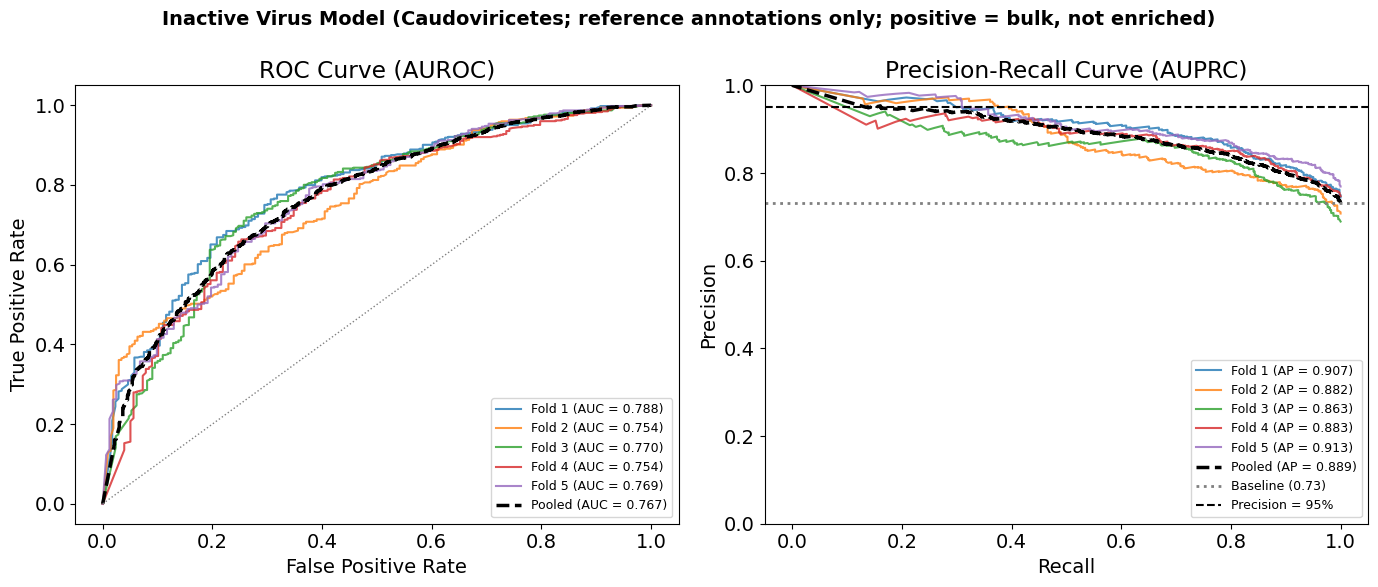

In [73]:
# Classifier: inactive (TP) vs active (FP) among bulk-detected Caudoviricetes.
# Reference-annotation features only (no CoverM / gene-breadth / Sylph coverage).
# GroupKFold by sample group to reduce patient-level leakage.

def run_activity_classifier(df_base, positive_pr_cat, model_title, target_col="target", feature_cols=None):
    """Group K-fold RF classifier for bulk-detected viruses.

    positive_pr_cat: 'TP' = inactive (bulk, not enriched)
    feature_cols: optional explicit feature list (defaults to REF_ONLY_FEATURES).
    """
    df = df_base[df_base["pr_cat"].isin(["TP", "FP"])].copy()
    df[target_col] = (df["pr_cat"] == positive_pr_cat).astype(int)

    n_pos = int(df[target_col].sum())
    n_neg = int((df[target_col] == 0).sum())
    print("=" * 60)
    print(model_title)
    print(f"Positive class ({positive_pr_cat}): {n_pos} | Negative class: {n_neg}")
    print("=" * 60)

    groups = df["group"]
    y = df[target_col]
    if feature_cols is None:
        feature_cols = list(REF_ONLY_FEATURES)
    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing classifier features: {missing}")
    X = df.reindex(columns=feature_cols)
    numeric_cols = list(feature_cols)

    preprocessor = ColumnTransformer(transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_cols),
    ])
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )),
    ])

    n_splits = min(5, df["group"].nunique())
    gkf = GroupKFold(n_splits=n_splits)

    fold_results = []
    all_y_test, all_y_proba, all_y_pred = [], [], []
    oof_proba = pd.Series(np.nan, index=df.index, dtype=float)
    oof_pred = pd.Series(pd.NA, index=df.index, dtype="Int64")
    fold_roc_curves, fold_pr_curves = [], []

    print(f"Starting Group K-Fold Cross-Validation (k={n_splits})")

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        test_index = df.index[test_idx]
        oof_proba.loc[test_index] = y_proba
        oof_pred.loc[test_index] = y_pred

        if len(np.unique(y_test)) > 1:
            auc = roc_auc_score(y_test, y_proba)
            auprc = average_precision_score(y_test, y_proba)
            mcc = matthews_corrcoef(y_test, y_pred)

            fpr, tpr, _ = roc_curve(y_test, y_proba)
            fold_roc_curves.append((fpr, tpr, auc))
            precision, recall, _ = precision_recall_curve(y_test, y_proba)
            fold_pr_curves.append((recall, precision, auprc))
        else:
            auc, auprc, mcc = np.nan, np.nan, np.nan

        fold_results.append({"fold": fold + 1, "AUROC": auc, "AUPRC": auprc, "MCC": mcc})
        all_y_test.extend(y_test.tolist())
        all_y_proba.extend(y_proba.tolist())
        all_y_pred.extend(y_pred.tolist())

    results_df = pd.DataFrame(fold_results).dropna()
    print(results_df.to_string(index=False))

    pooled_metrics = {}
    if len(np.unique(all_y_test)) > 1:
        pooled_metrics = {
            "AUROC": roc_auc_score(all_y_test, all_y_proba),
            "AUPRC": average_precision_score(all_y_test, all_y_proba),
            "MCC": matthews_corrcoef(all_y_test, all_y_pred),
        }
        print("\nPooled metrics across all folds:")
        print(f"  AUROC : {pooled_metrics['AUROC']:.3f}")
        print(f"  AUPRC : {pooled_metrics['AUPRC']:.3f}")
        print(f"  MCC   : {pooled_metrics['MCC']:.3f}")

    if len(fold_roc_curves) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle(model_title, fontsize=14, fontweight="bold")

        ax = axes[0]
        for i, (fpr, tpr, auc) in enumerate(fold_roc_curves):
            ax.plot(fpr, tpr, lw=1.5, alpha=0.8, label=f"Fold {i + 1} (AUC = {auc:.3f})")

        pool_fpr, pool_tpr, _ = roc_curve(all_y_test, all_y_proba)
        pool_auc = roc_auc_score(all_y_test, all_y_proba)
        ax.plot(
            pool_fpr, pool_tpr, color="black", lw=2.5, linestyle="--",
            label=f"Pooled (AUC = {pool_auc:.3f})",
        )
        ax.plot([0, 1], [0, 1], color="grey", lw=1, linestyle=":")
        ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curve (AUROC)")
        ax.legend(fontsize=9, loc="lower right")

        ax = axes[1]
        baseline = sum(all_y_test) / len(all_y_test)
        for i, (recall, precision, auprc) in enumerate(fold_pr_curves):
            ax.plot(recall, precision, lw=1.5, alpha=0.8, label=f"Fold {i + 1} (AP = {auprc:.3f})")

        pool_precision, pool_recall, _ = precision_recall_curve(all_y_test, all_y_proba)
        pool_ap = average_precision_score(all_y_test, all_y_proba)
        ax.plot(
            pool_recall, pool_precision, color="black", lw=2.5, linestyle="--",
            label=f"Pooled (AP = {pool_ap:.3f})",
        )
        ax.axhline(y=baseline, color="grey", lw=2, linestyle=":", label=f"Baseline ({baseline:.2f})")
        ax.axhline(y=0.95, color="black", lw=1.5, linestyle="--", label="Precision = 95%")
        ax.set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve (AUPRC)")
        ax.set_ylim(0, 1)
        ax.legend(fontsize=9, loc="lower right")

        plt.tight_layout()
        plt.show()

    final_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1,
        )),
    ])
    final_pipeline.fit(X, y)

    X_transformed = final_pipeline.named_steps["preprocessor"].transform(X)
    X_transformed_df = pd.DataFrame(X_transformed, columns=numeric_cols)

    return {
        "df": df,
        "y": y,
        "X": X,
        "numeric_cols": numeric_cols,
        "results_df": results_df,
        "pooled_metrics": pooled_metrics,
        "fold_roc_curves": fold_roc_curves,
        "fold_pr_curves": fold_pr_curves,
        "all_y_test": all_y_test,
        "all_y_proba": all_y_proba,
        "oof_proba": oof_proba,
        "oof_pred": oof_pred,
        "final_pipeline": final_pipeline,
        "X_transformed_df": X_transformed_df,
        "positive_pr_cat": positive_pr_cat,
        "model_title": model_title,
    }


df_base = enrich_v_unenrich_final.to_pandas()

inactive_results = run_activity_classifier(
    df_base,
    positive_pr_cat="TP",
    model_title="Inactive Virus Model (Caudoviricetes; reference annotations only; positive = bulk, not enriched)",
    target_col="is_inactive",
    feature_cols=REF_ONLY_FEATURES,
)

df = inactive_results["df"]
final_pipeline = inactive_results["final_pipeline"]
X_transformed_df = inactive_results["X_transformed_df"]
numeric_cols = inactive_results["numeric_cols"]
all_y_test = inactive_results["all_y_test"]
all_y_proba = inactive_results["all_y_proba"]


Generating SHAP summary plot for Inactive class (Class 1)...


/tmp/ipykernel_3405745/3260821226.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


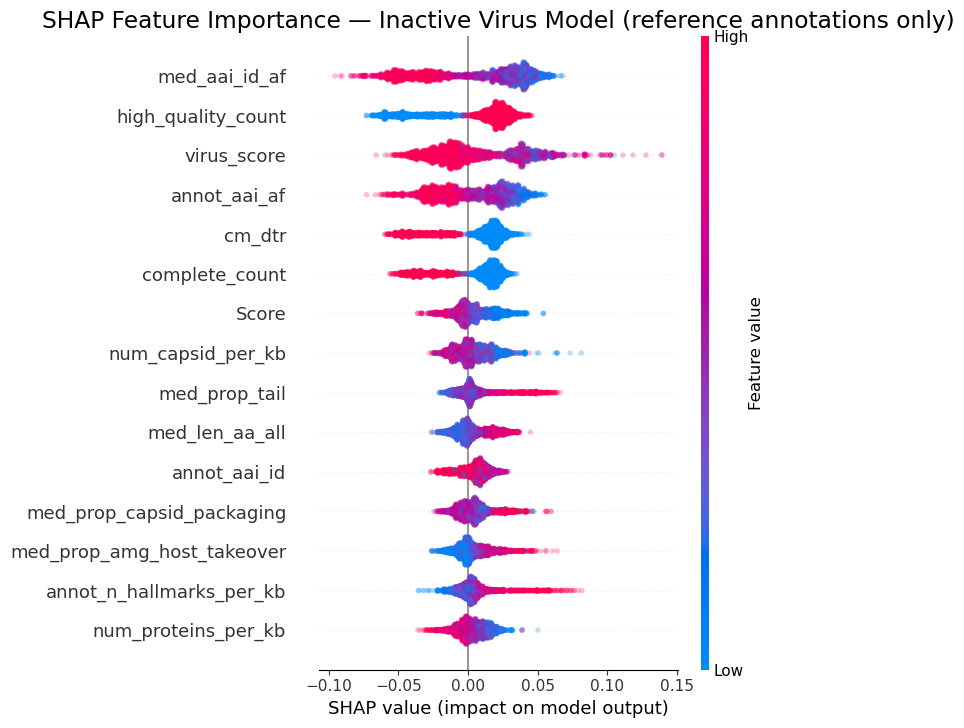

In [74]:
# Initialize SHAP explainer for inactive-virus model (reference-annotation features)
explainer = shap.TreeExplainer(final_pipeline.named_steps['classifier'])
shap_explanation = explainer(X_transformed_df)

print('Generating SHAP summary plot for Inactive class (Class 1)...')
shap.summary_plot(
    shap_explanation[:, :, 1],
    X_transformed_df,
    max_display=15,
    plot_type='dot',
    show=False,
    alpha=0.25,
)
plt.title('SHAP Feature Importance — Inactive Virus Model (reference annotations only)')
plt.tight_layout()
plt.show()


In [75]:
# Threshold calibration from OOF precision-recall curve.
# Joblib keys thresh_90 / thresh_75 / thresh_50 are kept for toolkit compatibility;
# here they map to 95% / 90% / 85% precision targets.
precisions, recalls, thresholds = precision_recall_curve(all_y_test, all_y_proba)


def get_target_metrics(target_precision, precisions, recalls, thresholds):
    """Return threshold with maximum recall among points meeting target precision."""
    valid_p = np.asarray(precisions[:-1])
    valid_r = np.asarray(recalls[:-1])
    idx = np.where(valid_p >= target_precision)[0]
    if len(idx) == 0:
        return {'threshold': 1.0, 'recall': 0.0}
    i = int(idx[np.argmax(valid_r[idx])])
    return {
        'threshold': float(thresholds[i]),
        'recall': float(valid_r[i]),
    }


metrics_90 = get_target_metrics(0.95, precisions, recalls, thresholds)
metrics_75 = get_target_metrics(0.9, precisions, recalls, thresholds)
metrics_50 = get_target_metrics(0.85, precisions, recalls, thresholds)

thresh_90, recall_90 = metrics_90['threshold'], metrics_90['recall']
thresh_75, recall_75 = metrics_75['threshold'], metrics_75['recall']
thresh_50, recall_50 = metrics_50['threshold'], metrics_50['recall']
print('-' * 30)
print('ESTIMATED PERFORMANCE (OOF, reference-annotation model):')
print(f'High Conf (95% Prec) -> Threshold: {thresh_90:.4f} | Est. Recall: {recall_90:.1%}')
print(f'Med  Conf (90% Prec) -> Threshold: {thresh_75:.4f} | Est. Recall: {recall_75:.1%}')
print(f'Low  Conf (85% Prec) -> Threshold: {thresh_50:.4f} | Est. Recall: {recall_50:.1%}')
print('-' * 30)


------------------------------
ESTIMATED PERFORMANCE (OOF, reference-annotation model):
High Conf (95% Prec) -> Threshold: 0.9920 | Est. Recall: 16.1%
Med  Conf (90% Prec) -> Threshold: 0.8424 | Est. Recall: 50.7%
Low  Conf (85% Prec) -> Threshold: 0.6626 | Est. Recall: 75.7%
------------------------------


In [76]:
# Save reference-only model under distinct filenames (do not overwrite coverage-based model).
model_metadata = {
    'numeric_cols': numeric_cols,
    'thresh_90': thresh_90,
    'thresh_75': thresh_75,
    'thresh_50': thresh_50,
    'ictv_class_filter': 'Caudoviricetes',
    'feature_set': 'ref_only',
    'n_features': len(REF_ONLY_FEATURES),
}

MODEL_PATH = 'phage_activity_model_ref_only.joblib'
META_PATH = 'phage_model_metadata_ref_only.joblib'
assert MODEL_PATH != 'phage_activity_model_full.joblib'
assert META_PATH != 'phage_model_metadata_full.joblib'

joblib.dump(final_pipeline, MODEL_PATH)
joblib.dump(model_metadata, META_PATH)

print(f'Saved {MODEL_PATH}')
print(f'Saved {META_PATH}')
print('Existing coverage-based model files were not modified.')


Saved phage_activity_model_ref_only.joblib
Saved phage_model_metadata_ref_only.joblib
Existing coverage-based model files were not modified.
